# 25188871 - CASA0006 Assignment

The entire code and data source can be accessed from this [GitHub link](https://github.com/mkbs-mkbs2000/MKBS_CASA0006_Assignment)!

In [1]:
import time
start_time = time.perf_counter()

In [2]:
import numpy as np
import pandas as pd
from functools import reduce
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score, matthews_corrcoef, make_scorer, recall_score, precision_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance
import shap

## Table of Contents

1. [Introduction](#Introduction)
2. [Research Question](#Research-Question)
3. [Data](#Data)
4. [Methodology](#Methodology)
5. [Results and Discussion](#Results-and-Discussion)
6. [Conclusion](#Conclusion)
7. [References](#References)

## 1. Introduction

Cycling in London has grown substantially over the past two decades, driven by investments in cycling infrastructure, public health campaigns promoting active transportation, and shifting attitudes toward sustainable mobility. Yet this growth has not come without costs. Between 2020 and 2024, Greater London recorded thousands of cyclist casualties, ranging from minor injuries to fatalities, highlighting an urgent need to better understand the factors that determine injury severity when collisions occur.

Existing road safety research has established that cyclist casualty severity is influenced by a complex interplay of environmental, infrastructural, and individual-level factors. Studies from Queensland, Australia have demonstrated that a range of variables such as collision time, road type, and age group significantly affect whether a cyclist sustains slight injuries or more serious harm (Komol et al., 2021). Research on bicycle-car crashes at intersections has similarly identified critical factors including vehicle speed, rider age, and intersection geometry as key determinants of injury outcomes (Bahrololoom et al., 2020). Meanwhile, comparative analyses of machine learning and statistical methods for crash severity prediction have shown that tree-based algorithms such as Random Forest often outperform traditional statistical approaches like multinomial logit models in handling the complex, non-linear relationships present in crash data (Wahab & Jiang, 2019). The application of supervised machine learning algorithms to crash severity analysis has emerged as a promising modelling tool, offering advantages in handling data outliers, noisy data, and missing values without requiring presumed mathematical functions (Komol et al., 2021).

Thus, this exercise aims to address the gap in literature by developing a predictive model about the severity of cyclist casualty in Greater London.

## 2. Research Question

**Can cyclist casualty severity in Greater London be predicted from environmental, infrastructural and collision-area deprivation features? And which factors matter most?**


## 3. Data

The data is sourced from the following places:

1) *Environmental features* - STATS19 Road Safety Data on Collisions, Vehicles and Casualties for the last 5 years (2020 - 2024), sourced from [Department for Transport (2025)](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data).

2) *Sociodemographic features* - English Indices of Deprivation 2025 (File 7: All ranks, scores, deciles and population denominators for the Indices of Deprivation), sourced from [Ministry of Housing, Communities and Local Government (2025)](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025)

3) *Infrastructural features [TfL-managed Roads]* - sourced from [Transport for London GIS Open Data Hub (2022)](https://gis-tfl.opendata.arcgis.com/datasets/transport-for-london-road-network-tlrn-1/about)

4) *Infrastructural features [Cycle lane features]* - sourced from [Transport for London Cycling Data (2021)](https://cycling.data.tfl.gov.uk/)

---

Specifically the following data will be of interest in this exercise:

**Target Feature**: Casualty Severity, Binary, 1 for KSI (Severe and Fatal) / 0 for Slight

| Data | Type | Feature Type | Definition |
| --- | --- | --- | --- |
| No. of Vehicles | Continuous | Environmental | Captures how many vehicles were involved in that accident involving the cyclist |
| Type of Vehicles (has car/has motorcycles/etc) | Binary | Environmental | Capturing presence of other vehicle types in a collision vis-a-vis self-collisions |
| Date | String | Environmental | - |
| Day of Week | String | Environmental | - |
| Time | String | Environmental | - |
| Road Type | Categorical | Environmental | Roundabout, One way street, Dual carriageway, Single carriageway, Slip road |
| Road Classification | Categorical | Environmental | Motorway, A, B, C, Unclassified (Local Roads) |
| Carriageway Hazard | Categorical | Environmental | Defective traffic signals, Roadworks object as hazard, etc. |
| Special Conditions | Categorical | Environmental | General roadwork conditions, etc. |
| Age of cyclist | Continuous | Environmental | - |
| Sex of cyclist | Binary | Environmental | 1 for Male, 2 for Female |
| Skidding/Overturning | Categorical | Environmental | Skidding, Overturning, Skidding and Overturning |
| Hit Object Off/On Carriageway | Categorical | Environmental | Parked vehicle, Open door, Kerb, etc. |
| Journey Purpose | Categorical | Environmental | Part of work, To/from work, School run, Leisure |
| Junction Detail | Categorical | Environmental | T/Staggered junction, Crossroads/Standard junction, Non-standard junction, Private driveway |
| Junction Location | Categorical | Environmental | Junction approach/exit, Leaving/entering roundabout, Leaving/entering main road, Entering from slip road |
| Presence in Restricted Lane | Categorical | Environmental | On normal lane, In bus lane, In on-road cycle lane, In off-road cycle lane, In emergency lane, On footpath |
| First Point of Impact | Categorical | Environmental | Front, Back, Offside, Nearside |
| --- | --- | --- | --- |
| is TfL managed | Binary | Infrastructural | Captures if accident location is on a TfL-managed road, proxy for how busy/important that road is |
| CLT-SEGREG | Binary | Infrastructural | Captures if cycle lane near accident location is a segregated lane |
| CLT-PARSEG | Binary | Infrastructural | Captures if cycle lane near accident is a partially-segregated lane |
| CLT-STEPP | Binary | Infrastructural | Captures if cycle lane near accident is a stepped lane from the carriageway |
| CLT-SHARED | Binary | Infrastructural | Captures if cycle lane near accident is shared with another priority lane (bus lane) |
| CLT-MANDAT | Binary | Infrastructural | Captures if cycle lane near accident is a mandatory cycle lane |
| CLT-ADVIS | Binary | Infrastructural | Captures if cycle lane near accident is an advisory cycle lane |
| --- | --- | --- | --- |
| Income Domain Score | Continuous | Deprivation | Captures collision-area low-income prevalence amongst its residents |
| Employment Domain Score | Continuous | Deprivation | Captures collision-area unemployment prevalence amongst its residents |
| Health Deprivation and Disability Domain Score | Continuous | Deprivation | Captures collision-area's poor health outcomes amongst its residents |
| Crime Domain | Continuous | Deprivation | Captures collision-area crime rate |
| Barriers to Housing and Services Domain Score | Continuous | Deprivation | Captures collision-area difficulting in accessing public services |
| Indoors Sub-Domain Score | Continuous | Deprivation | Captures collision-area's poor housing conditions


The rationale of splitting this up into the domain/sub-domain instead of using the IMD Decile data already provided in STATS19 is because the Outdoors Sub-Domain (also part of the Living Environment Domain) takes into account pedestrian and cyclist collisions within the LSOA, possibly leading to a problem of circularity. Albeit a small issue, there is still an opportunity to remove this problem, thus the decision to bring in the domains separately instead of aggregated as in STATS19. Furthermore, it can add more clarity on which aspects of deprivation could be negatively associated with cyclist safety and casualty severity.


#### 3.1 Data Pooling

The data pooling process will produce a GeoDataFrame gpd_full_flagged where each row is a cyclist casualty, its recorded casualty severity, followed by all the other features.

In [3]:
# Extracting LSOA codes within Greater London
lsoa = pd.read_csv(
    'data/RM055_LC5107EW.csv'
)

lsoa_code = lsoa['lsoa21cd'].unique()

In [4]:
# Loading collisions data first
location = pd.read_csv(
    'data/dft-road-casualty-statistics-collision-last-5-years.csv'
)

# Extracting relevant information from the collisions data
col_needed = [
    'collision_index',
    'longitude',
    'latitude',
    'number_of_vehicles',
    'date',
    'day_of_week',
    'time',
    'first_road_class',
    'road_type',
    'speed_limit',
    'junction_detail',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'special_conditions_at_site',
    'carriageway_hazards',
    'lsoa_of_accident_location'
]
location = location[col_needed]

# Subsetting it to collisions within Greater London
lon_location = location[location['lsoa_of_accident_location'].isin(lsoa_code)]

# Converting date to month of collision data
lon_location['month'] = pd.to_datetime(
    lon_location['date'],
    format = '%d/%m/%Y'
).dt.month

# Converting time to hour of collision data
lon_location['hour'] = pd.to_datetime(
    lon_location['time'],
    format = '%H:%M'
).dt.hour

C:\Users\mkbs_\AppData\Local\Temp\ipykernel_39524\2186775959.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lon_location['month'] = pd.to_datetime(
C:\Users\mkbs_\AppData\Local\Temp\ipykernel_39524\2186775959.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lon_location['hour'] = pd.to_datetime(


In [5]:
# Loading casualties data 
casualty = pd.read_csv(
    'data/dft-road-casualty-statistics-casualty-last-5-years.csv'
)

# Specifying for casualties of accidents in Greater London
lon_casualty = casualty[casualty['collision_index'].isin(lon_location['collision_index'].unique())]

# Specifying for cyclist casualties only
lon_cyc = lon_casualty[lon_casualty['casualty_type'] == 1]

# Clearing for unknown or unspecified sex of casualty
lon_cyc_cas = lon_cyc[lon_cyc['sex_of_casualty'].isin([1,2])]
    
# Extracting relevant information from the casualty data 
col_needed = [
    'collision_index',
    'vehicle_reference',
    'sex_of_casualty',
    'age_of_casualty',
    'casualty_severity'
]
lon_cyc_cas = lon_cyc_cas[col_needed]

# Reclassifying casualty_severity to put Fatal (1) and Severely Injured (2) into one category
lon_cyc_cas['casualty_severity'] = lon_cyc_cas['casualty_severity'].isin([1, 2]).astype(int)

In [6]:
# Loading vehicles data
vehicles = pd.read_csv(
    'data/dft-road-casualty-statistics-vehicle-last-5-years.csv'
)

# Extracting relevant information from the vehicles data
col_needed = [
    'collision_index',
    'vehicle_reference',
    'vehicle_type',
    'skidding_and_overturning',
    'vehicle_location_restricted_lane',
    'junction_location',
    'hit_object_in_carriageway',
    'hit_object_off_carriageway',
    'first_point_of_impact',
    'journey_purpose_of_driver'
]
vehicles = vehicles[col_needed]

# Specifying for vehicles involved in accidents with cyclist casualties in Greater London 
lon_vehicles = vehicles[vehicles['collision_index'].isin(lon_cyc_cas['collision_index'].unique())]


# Converting vehicles data into three boolean columns to indicate if other vehicles are involved in the accident
motorcycle = [2, 3, 4, 5, 23, 97]
car = [8, 9]
heavy_veh = [10, 11, 19, 20, 21]

vehicle_flag = lon_vehicles.groupby(
    'collision_index'
).agg(
    has_motorcycle = ('vehicle_type', lambda x: int((x.isin(motorcycle)).any())),
    has_car = ('vehicle_type', lambda x: int((x.isin(car)).any())),
    has_heavy_vehicles = ('vehicle_type', lambda x: int((x.isin(heavy_veh)).any()))
).reset_index()

C:\Users\mkbs_\AppData\Local\Temp\ipykernel_39524\2307726944.py:2: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles = pd.read_csv(


In [7]:
# Getting more details of what the cyclist was doing
lon_cyclist_veh = lon_cyc_cas[['collision_index', 'vehicle_reference']].merge(
    lon_vehicles,
    on = ['collision_index', 'vehicle_reference'],
    how = 'left'
)

In [8]:
# Merging them all together, the core dataset is lon_cyc_cas
lon_cyc_info = reduce(
    lambda x, y: pd.merge(x, y, how = 'left', on = 'collision_index'),
    (lon_cyc_cas, lon_location, vehicle_flag)
)

lon_cyc_dataset = lon_cyc_info.merge(
    lon_cyclist_veh,
    how = 'left',
    on = ['collision_index', 'vehicle_reference']
).drop(
    columns = 'vehicle_reference'
)

In [9]:
# Loading IMD Domain Scores
imd = pd.read_csv(
    'data/File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv'
)

# Extracting relevant information from the IMD data
col_needed = [
    'LSOA code (2021)',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
    'Barriers to Housing and Services Score',
    'Indoors Sub-domain Score' #sub-domain of Living Environment Domain in IMD
]
imd = imd[col_needed]

# Merging it with lon_cyc_dataset
lon_cyc_imd = lon_cyc_dataset.merge(
    imd,
    left_on = 'lsoa_of_accident_location',
    right_on = 'LSOA code (2021)',
    how = 'left'
).drop(
    columns = 'LSOA code (2021)'
)

In [10]:
# Converting into GDF so as to be able to identify if accident location is on a TFL-managed road or near cycle lane infrastructure
lon_cyc_gpd = gpd.GeoDataFrame(
    lon_cyc_imd,
    geometry = gpd.points_from_xy(
        lon_cyc_dataset['longitude'],
        lon_cyc_dataset['latitude'],
        crs = 'EPSG:4326'
    )
).to_crs(
    27700
).drop(
    columns = ['latitude', 'longitude']
)

# Isolating the collisions index and geometry for the purposes of nearest spatial join
data_subset = lon_cyc_gpd[['collision_index', 'geometry']]

In [11]:
# Loading data on roads managed by TfL
tfl_roads = gpd.read_file(
    'data/Transport_for_London_Road_Network_(TLRN).geojson'
).to_crs(27700)

# Joining nearest TfL data to the subset of cyclist casualty GDF within a 5 metre distance
tfl_flag = data_subset.sjoin_nearest(
    tfl_roads[['geometry']],
    how = 'left',
    max_distance = 5,
    distance_col = 'distance'
).sort_values(
    ['collision_index', 'distance']
).drop_duplicates(
    'collision_index'
).drop(
    columns = 'geometry'
)

# Merging this data with the original GDF
gpd_tfl_flagged = lon_cyc_gpd.merge(
    tfl_flag,
    on = 'collision_index',
    how = 'left'
)

# Having a new column to indicate that casualty was injured on a TfL-managed road
gpd_tfl_flagged['is_tfl_managed'] = gpd_tfl_flagged['distance'].notna().astype(int)

# Dropping non-relevant columns
gpd_tfl_flagged = gpd_tfl_flagged.drop(
    columns = ['index_right', 'distance']
)

In [12]:
# Loading data on cycle lanes
cycle_lane = gpd.read_file(
    'data/cycle_lane_track.json'
).to_crs(27700)

# Specifying for cycle lanes that are on the carriageway
cycle_lane = cycle_lane[cycle_lane['CLT_CARR'] == 'TRUE']

# Extracting relevant information from the cycle lanes data
col_needed = [
    'CLT_SEGREG',
    'CLT_PARSEG',
    'CLT_STEPP',
    'CLT_SHARED',
    'CLT_MANDAT',
    'CLT_ADVIS',
    'geometry'
]
cycle_lane = cycle_lane[col_needed]

# Joining nearest cycle lanes data to the subset of cyclist casualty GDF within a 5 metre distance
cycle_lane_flag = data_subset.sjoin_nearest(
    cycle_lane,
    how = 'left',
    max_distance = 5,
    distance_col = 'distance'
).sort_values(
    ['collision_index', 'distance']
).drop_duplicates(
    'collision_index'
).drop(
    columns = ['geometry', 'index_right']
)

# Merging this data with the post-TfL-update GDF of cycling casualties
gpd_full_flagged = gpd_tfl_flagged.merge(
    cycle_lane_flag,
    on = 'collision_index',
    how = 'left'
)

# Having a new column to indicate that casualty was injured on a cycle lane
gpd_full_flagged['nearby_cycle_lane'] = gpd_full_flagged['distance'].notna().astype(int)

# Reformatting columns from cycle lanes data
col_reformatted = [c for c in col_needed if c != 'geometry']
gpd_full_flagged[col_reformatted] = gpd_full_flagged[col_reformatted].eq('TRUE').astype(int)

# Dropping non-relevant columns
gpd_full_flagged = gpd_full_flagged.drop(
    columns = 'distance'
)

c:\Users\mkbs_\anaconda3\envs\urbsim\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 6482-04-01, at position 157. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


#### 3.2 Exploratory Data Analysis

An issue encountered when looking at the data is that the environmental features contain a lot of 'unknown' or 'data missing'. Thus, a brief EDA on the prevalence of cyclist casualty incidences based on environmental factors is done, to inform how data will be manipulated.

>>> SECTION 1: Dataset Overview & Class Distribution


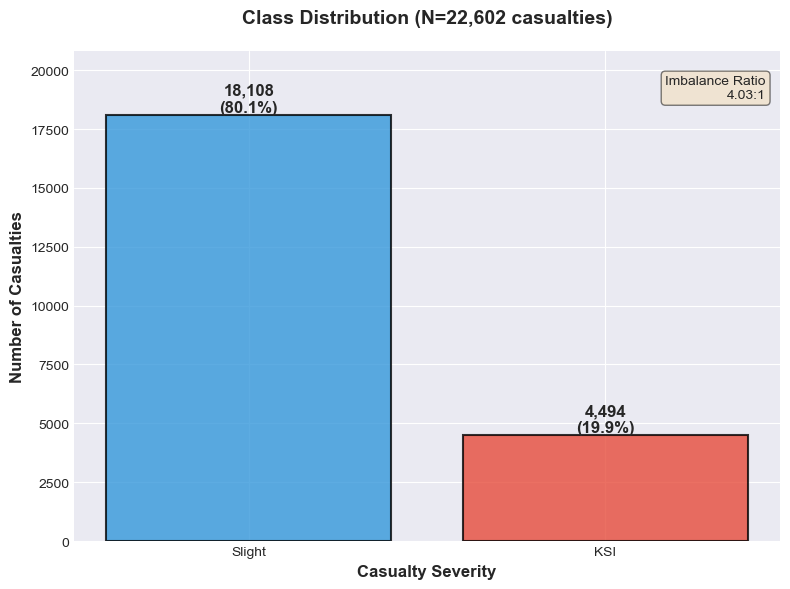


>>> SECTION 2: Temporal Patterns


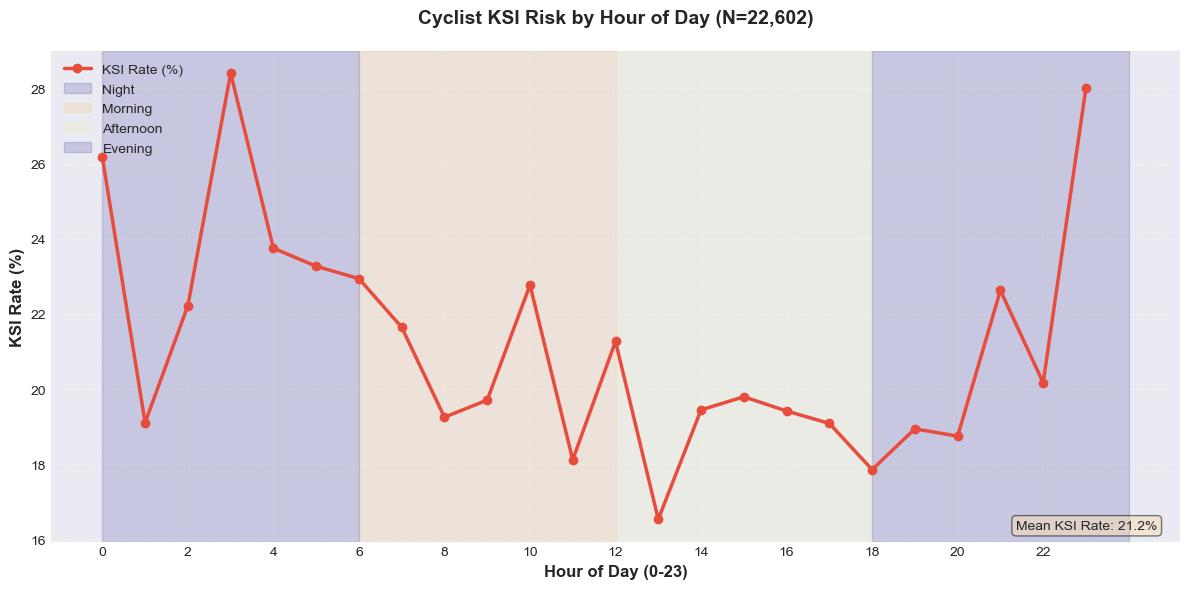

c:\Users\mkbs_\Documents\UCL\03 DSSS\Assignment\eda_plots_complete.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_data = df_temp.groupby(['day_name', 'time_period'])[target_col].agg(['mean', 'count'])


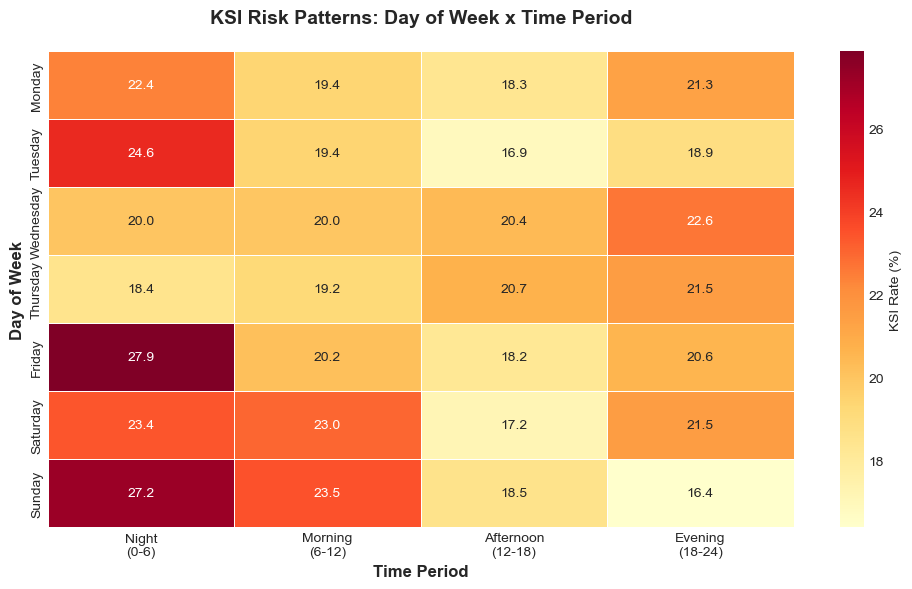

c:\Users\mkbs_\Documents\UCL\03 DSSS\Assignment\eda_plots_complete.py:204: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_temp['year_month'] = pd.to_datetime(df_temp[date_col]).dt.to_period('M')


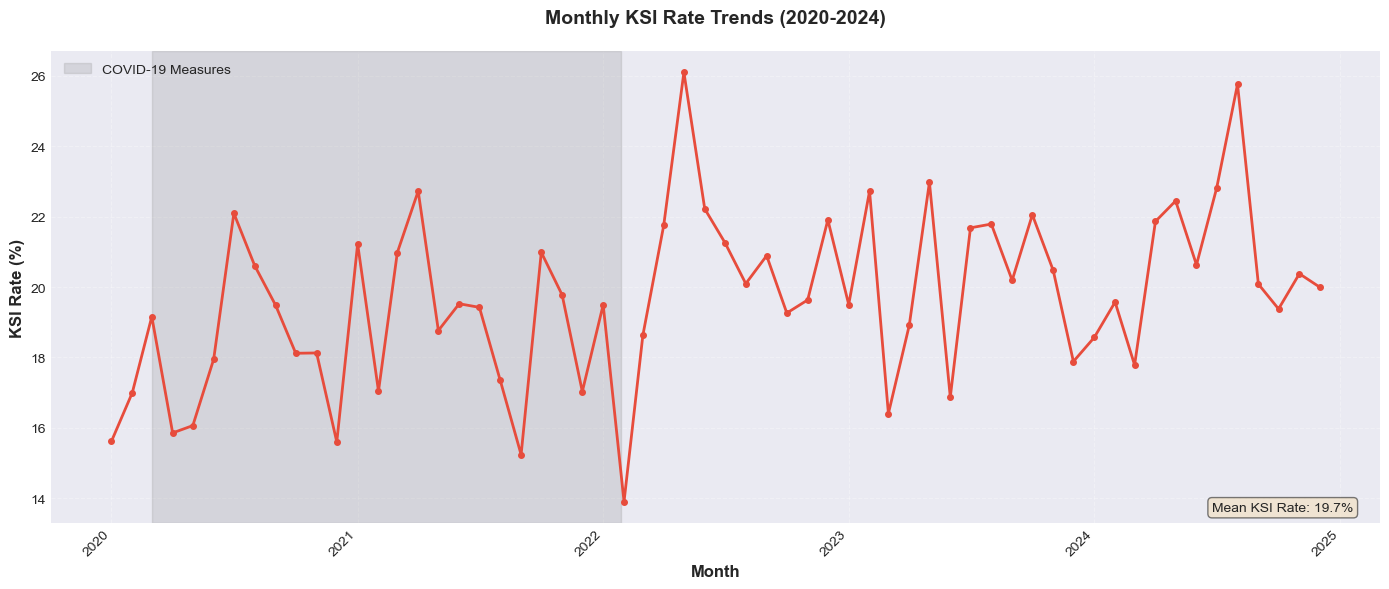


>>> SECTION 3: Data from STATS19


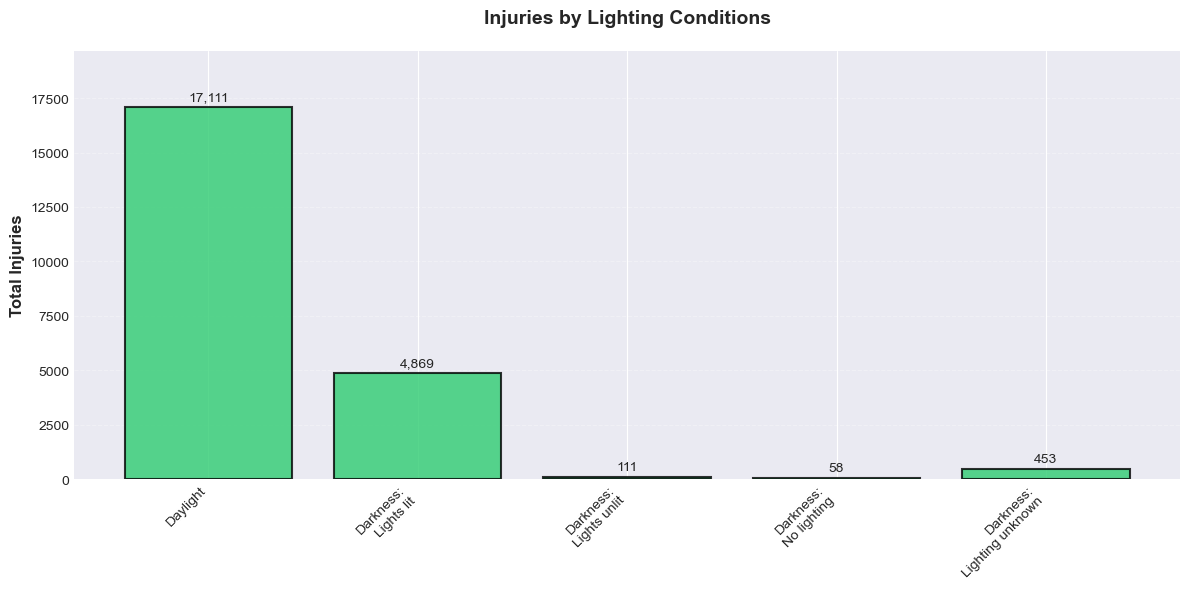

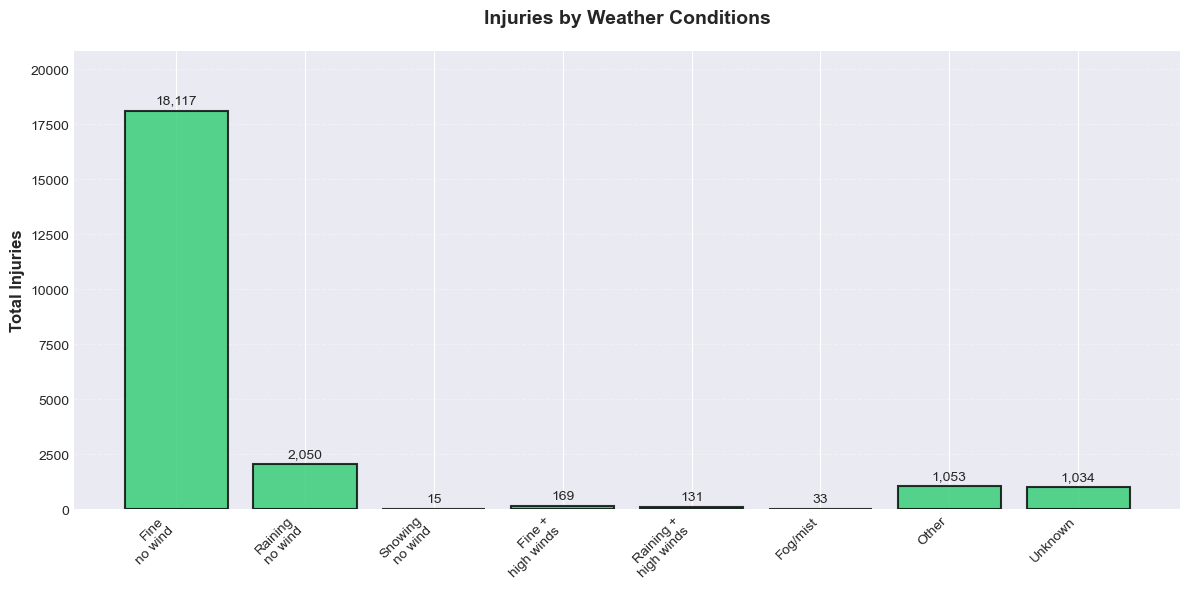

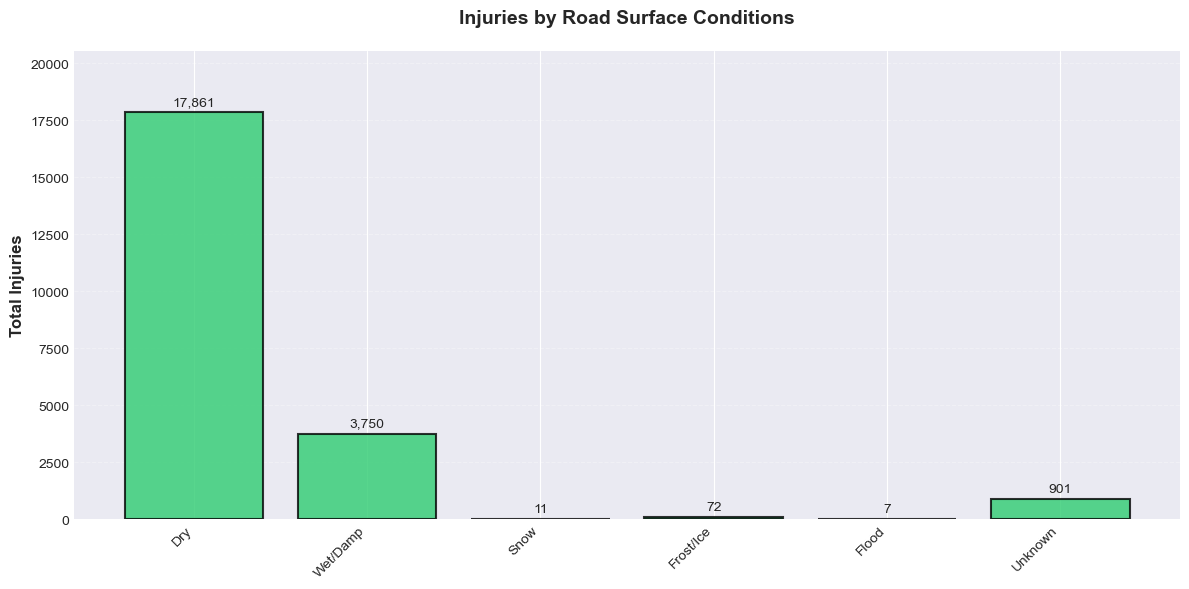

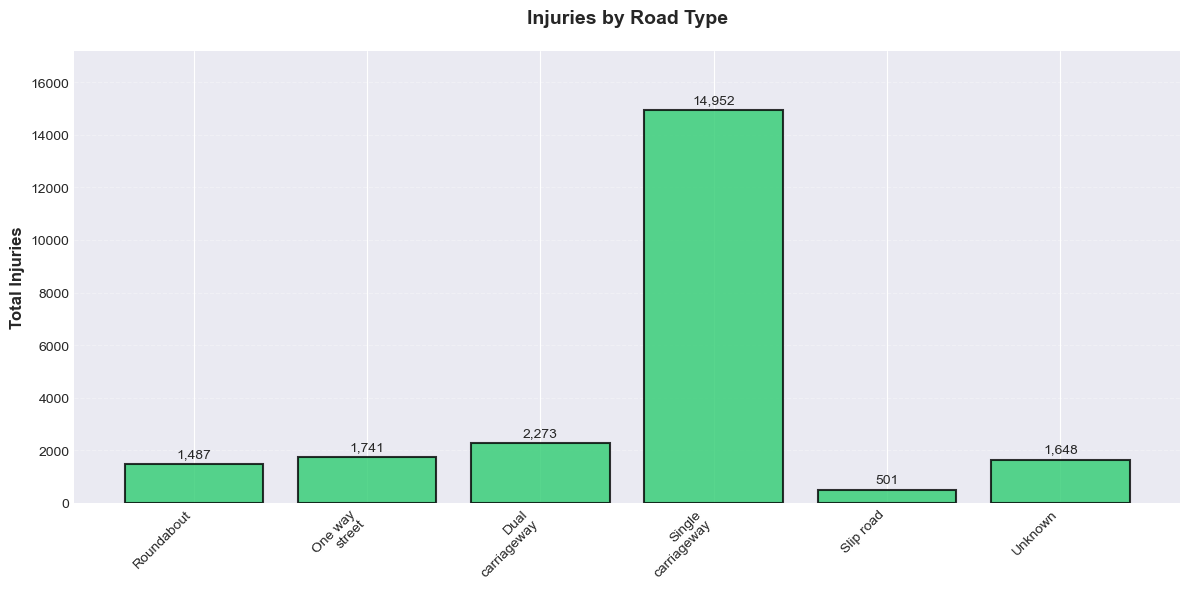

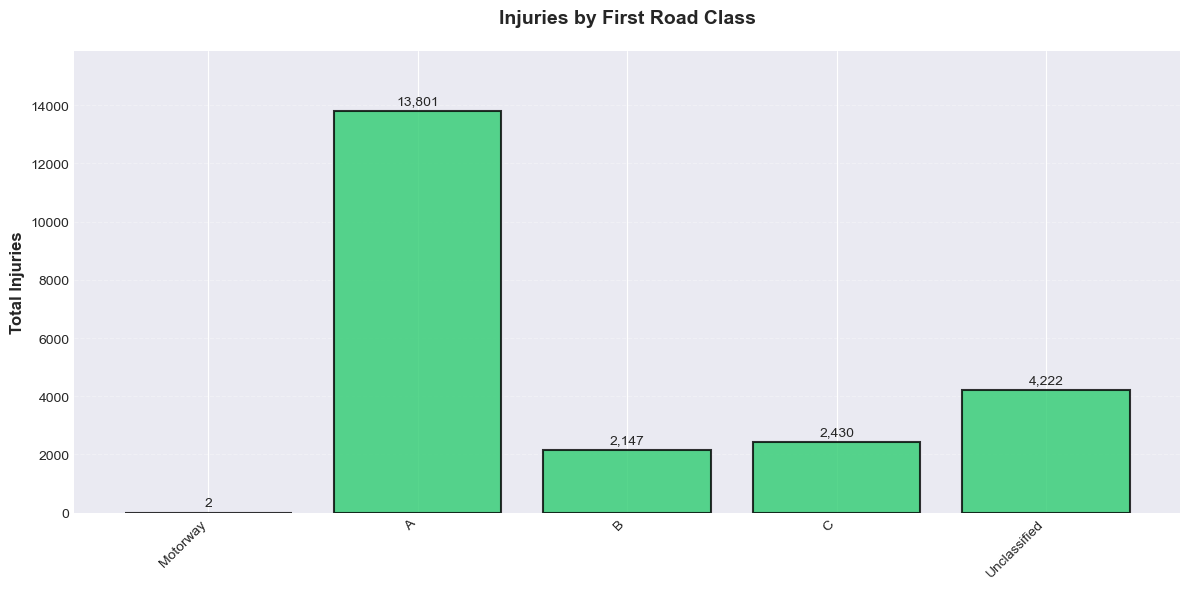

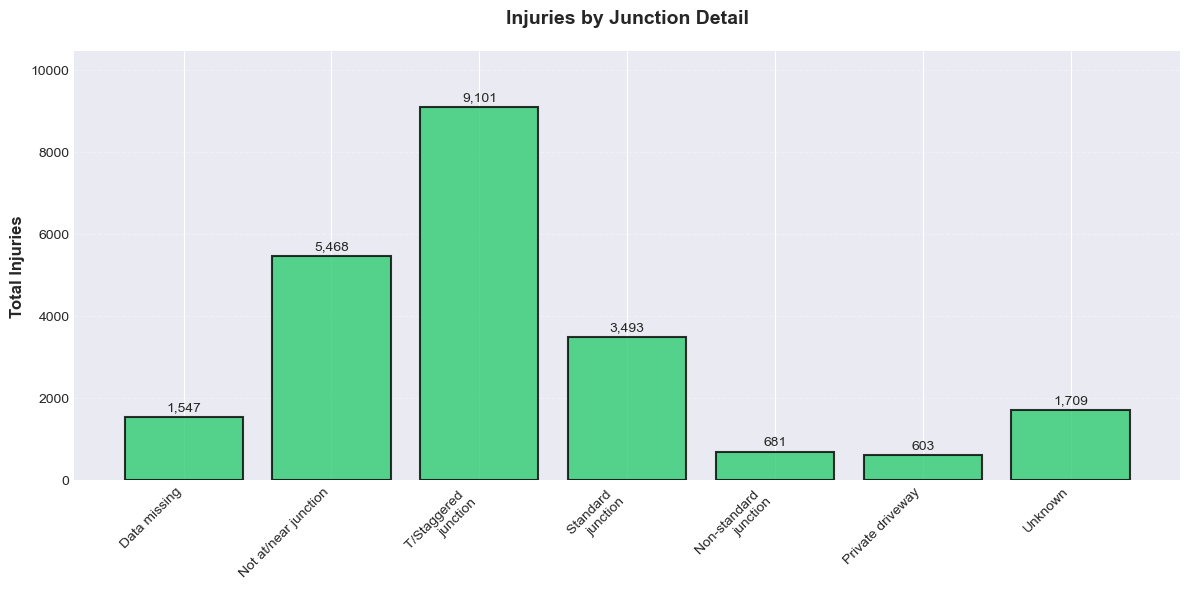

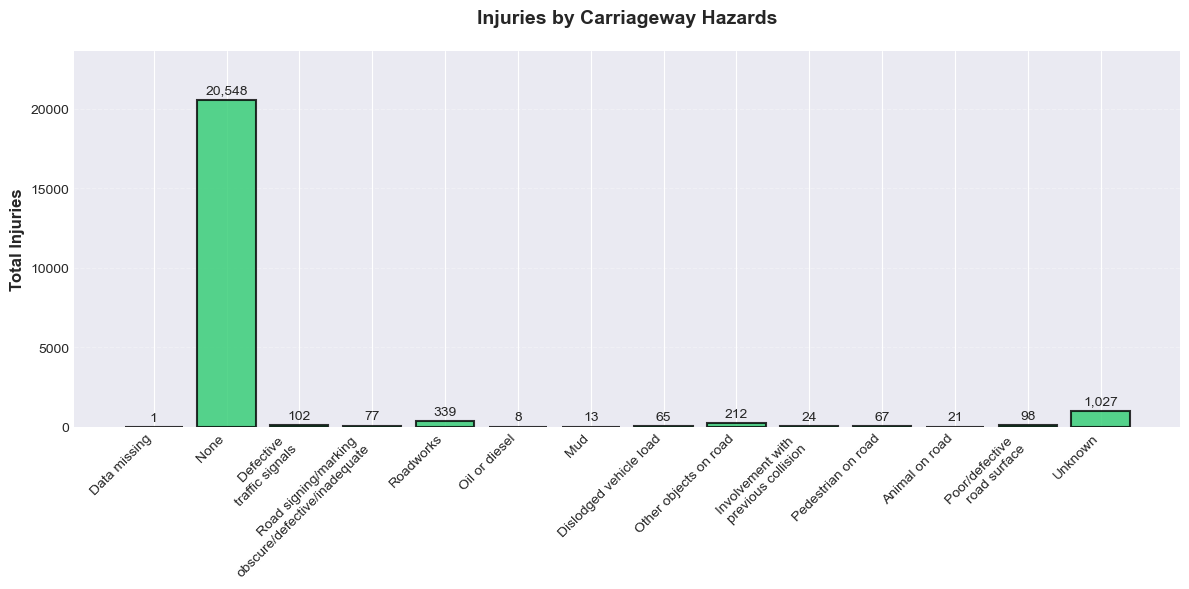

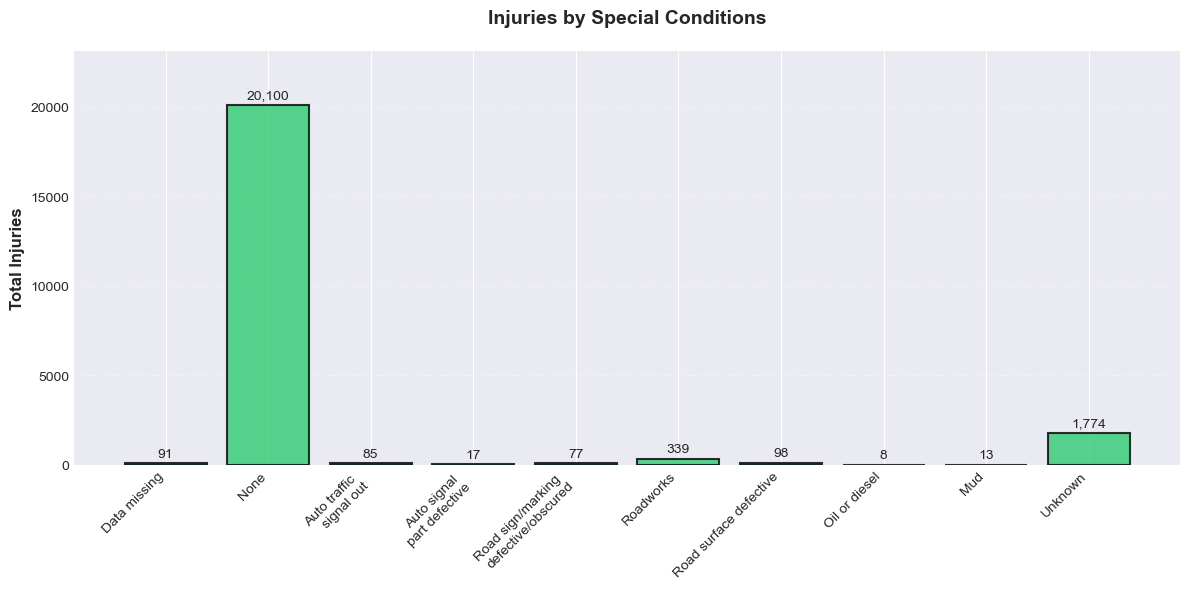

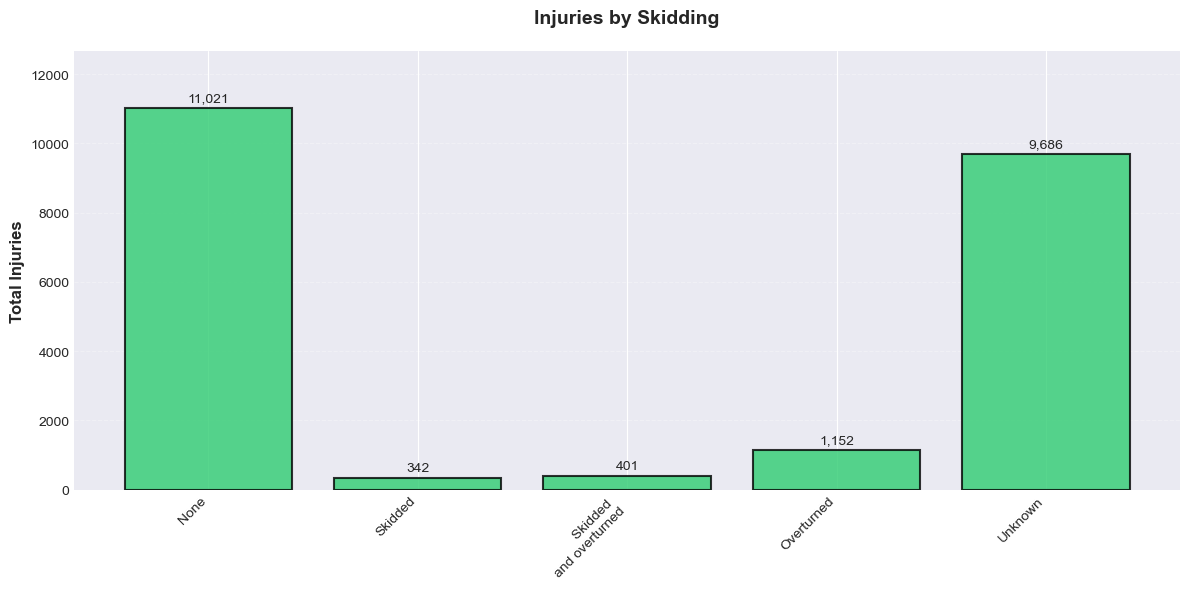

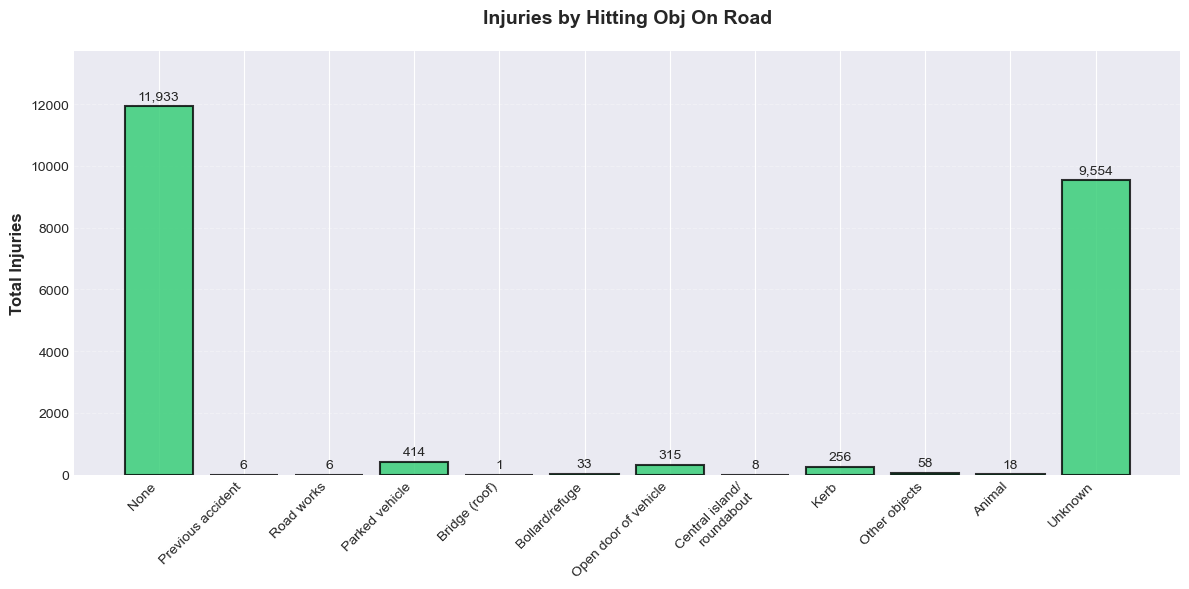

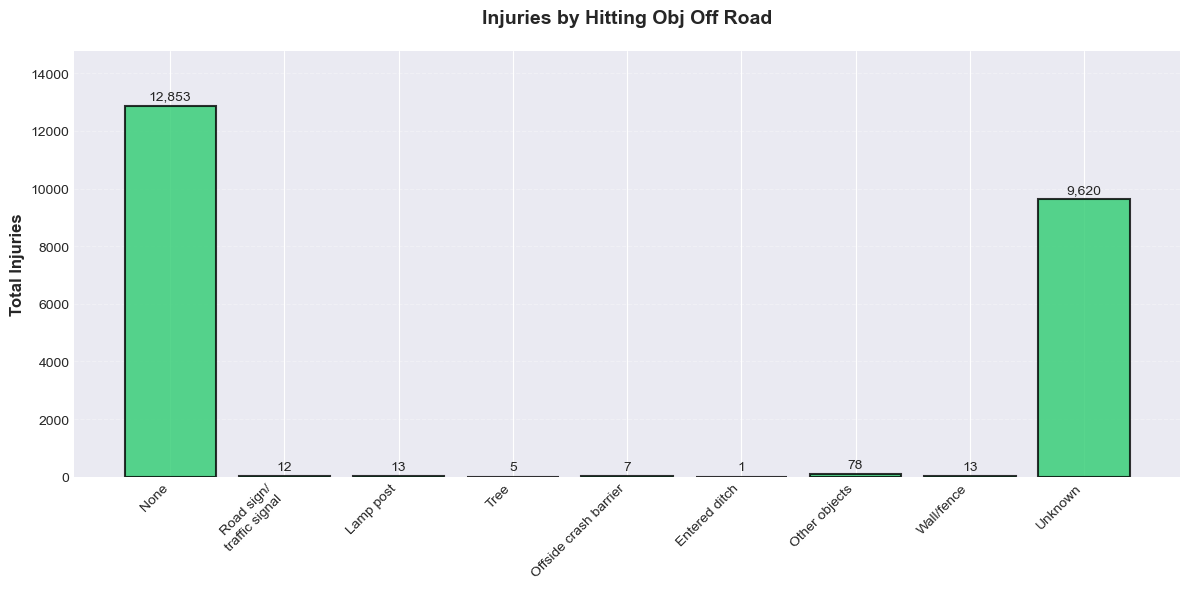

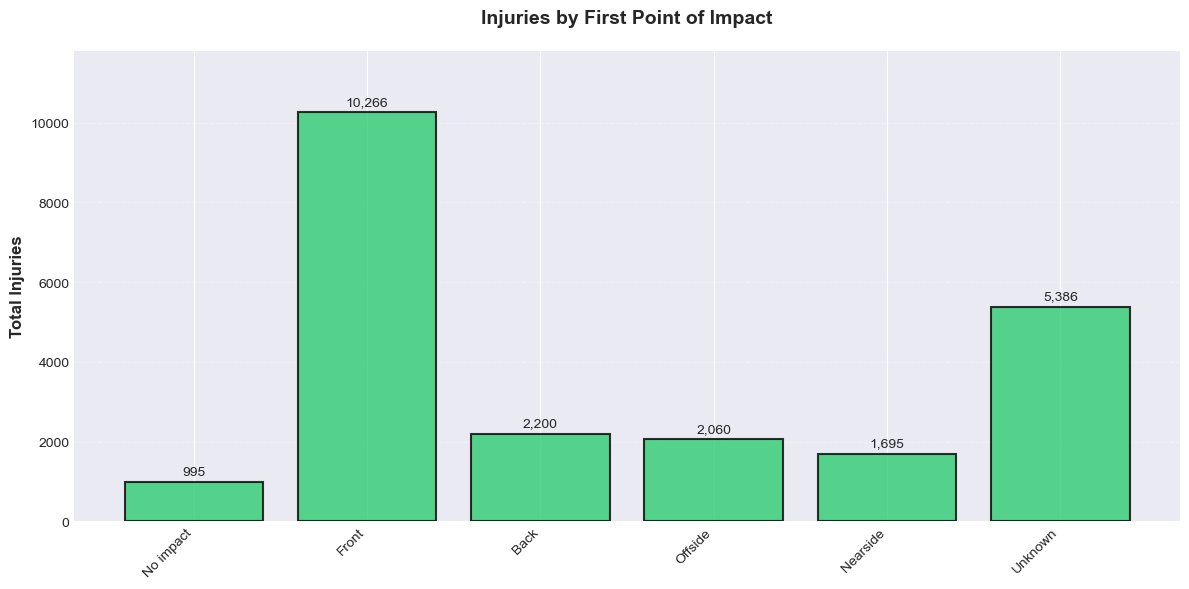

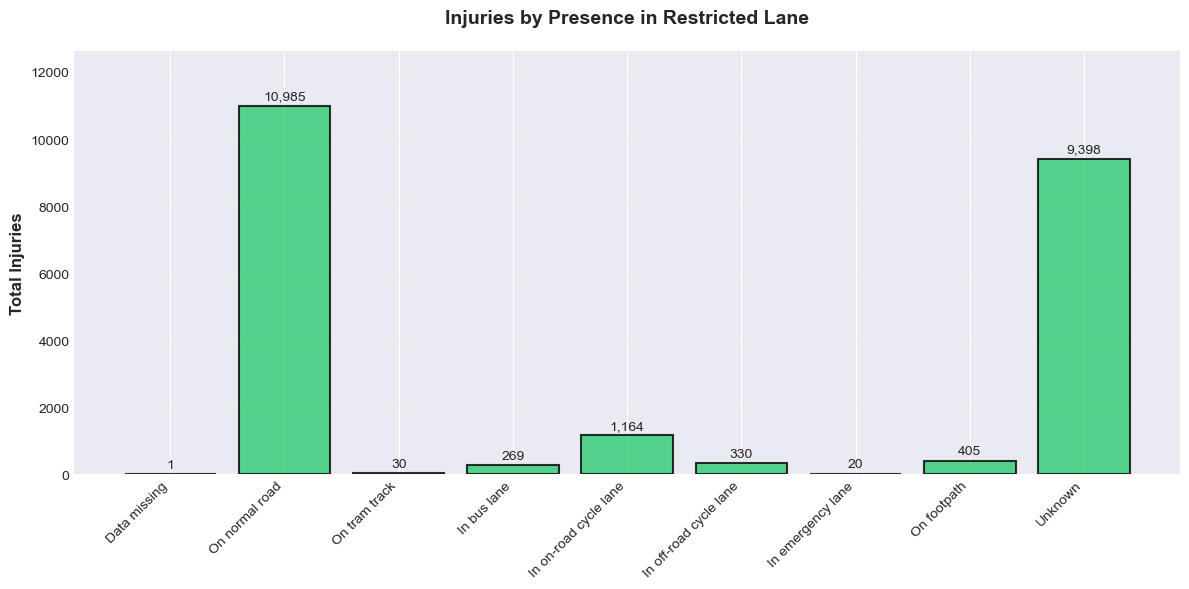

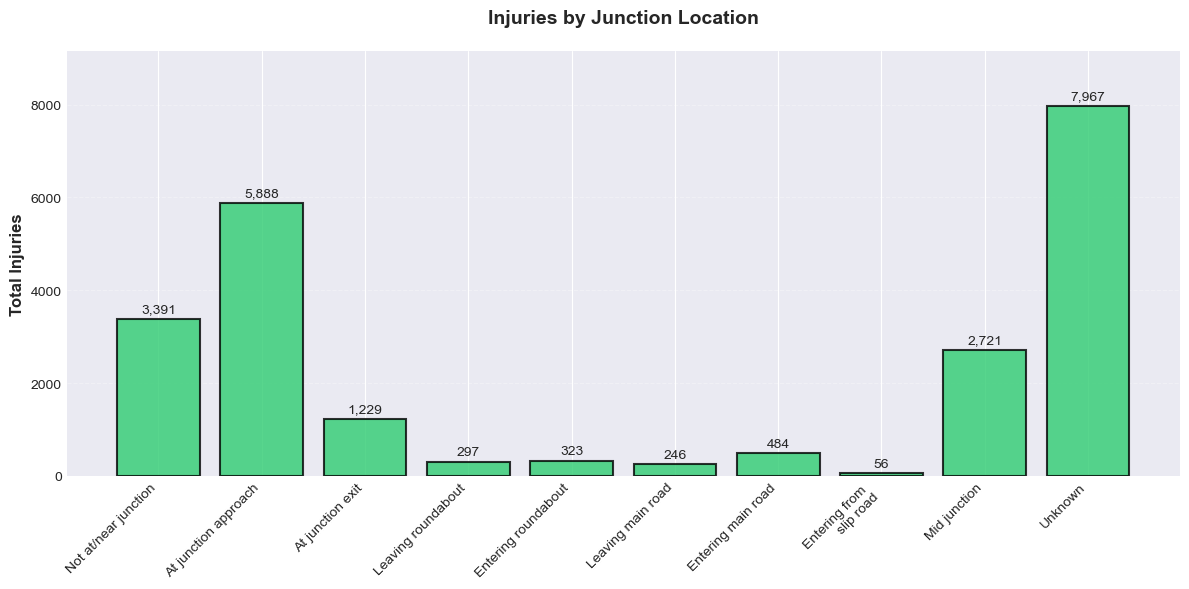

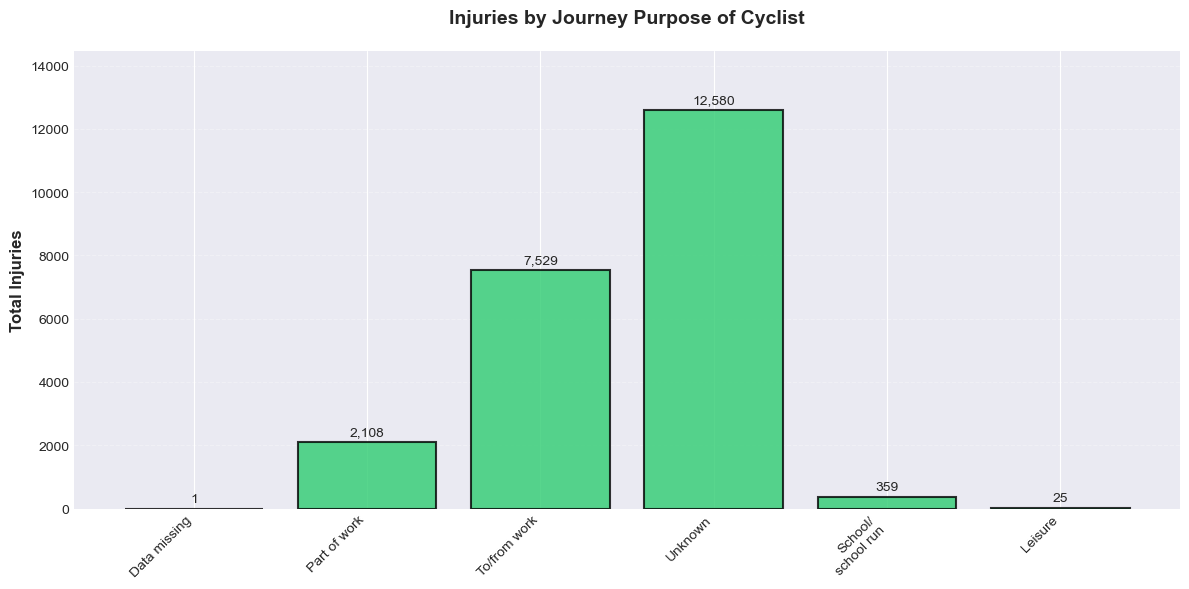

In [13]:
# Import code from py file to display the graphs on STATS19 data
from eda_plots_complete import run_complete_eda

run_complete_eda(gpd_full_flagged)

#### 3.3 Further Data Manipulation

We can see that almost every environmental feature about an accident that is tied to cyclist injuries have instances where it could be unknown. The simple option of removing rows where there are data that refers to 'Unknown' or 'Data Missing' will not be wise because it may lead to removal of thousands of rows. As such, the following will be how the environmental features will be manipulated

--- 

*To be Transformed - some of the STATS19 classifications are overlapping*  
- Light conditions data to be transformed into three new binary features: 'during daylight', 'has light', 'no light'  
- Weather conditions data to be transformed into three new binary features: 'fine', 'has rain', 'has wind'  
- Skidding data to be transformed into three new binary features: 'just crashed', 'skidded', 'overturned'
- Hit object off carriageway to be transformed into one binary feature: 'hit offroad'

Unknowns in the these features would naturally have False for all of them, thus not affecting the model.  

---

*To be Simplified - the STATS19 classifications are separate and distinct enough, but instances of injuries are less than 100, so they can be combined into an 'Others' classification*  
- Road surface conditions simplified into ['dry', 'wet/damp', 'others']
- Carriageway hazards simplified into ['none', 'roadworks', 'defective traffic signals', 'others']
- Special conditions simplified into ['none', 'roadworks', 'others']
- Hit object in carriageway simplified into ['none', 'parked vehicle', 'open door', 'kerb', others'] 
- Presence in restricted lane simplified into ['normal road', 'on-road cycle lane', 'off-road cycle lane', 'footpath', 'bus lane', 'others'] 

---

*Keep it as it is - STATS19 classifications are separate and distinct enough, and the instances of injuries in each classification is above 100*  
- First road class *
- Junction detail
- First point of impact
- Junction location  
- Journey purpose of cyclist
- Road type

However, they still need to be relabeled because data for them is currently in number codes instead of in string.

---

For *To be Simplified* and *Keep it as it is*, 'Unknown' or 'Data missing', if present, will be reclassified as 'A', so that it will be the first to drop when doing one-hot encoding. 

*For first road class, there are two instances of injuries on motorways, where cyclists are not even allowed in the first place. These two injuries would be filtered out right at the start!

In [14]:
# Filtering out injuries that occurred on motorways (first_road_class = 1)
cleaned_dataset = gpd_full_flagged[gpd_full_flagged['first_road_class'] != 1]

# Converting light_conditions into various binary data
cleaned_dataset['during_daylight'] = (cleaned_dataset['light_conditions'] == 1).astype(int)
cleaned_dataset['has_light'] = cleaned_dataset['light_conditions'].isin([1, 4]).astype(int)
cleaned_dataset['no_light'] = cleaned_dataset['light_conditions'].isin([5, 6]).astype(int)

# Converting weather_conditions into various binary data 
cleaned_dataset['fine_weather'] = (cleaned_dataset['weather_conditions'] == 1).astype(int)
cleaned_dataset['has_rain'] = cleaned_dataset['weather_conditions'].isin([2, 5]).astype(int)
cleaned_dataset['has_wind'] = cleaned_dataset['weather_conditions'].isin([4, 5, 6]).astype(int)

# Converting skidding into various binary data
cleaned_dataset['just_crashed'] = (cleaned_dataset['skidding_and_overturning'] == 0).astype(int)
cleaned_dataset['skidded'] = cleaned_dataset['skidding_and_overturning'].isin([1, 2]).astype(int)
cleaned_dataset['overturned'] = cleaned_dataset['skidding_and_overturning'].isin([2, 5]).astype(int)

# Converting hit_object_off_carriageway into binary data
cleaned_dataset['hit_offroad'] = cleaned_dataset['hit_object_off_carriageway'].isin([1,2,4,6,9,10,11]).astype(int)

# Simplifying road_surface_conditions data classifications
surface_labels = {
    1: 'Dry',
    2: 'Wet/Damp',
    3: 'Others',
    4: 'Others',
    5: 'Others',
    9: 'A'
}
cleaned_dataset['road_surface_conditions'] = cleaned_dataset['road_surface_conditions'].map(surface_labels)

# Simplifying carriageway_hazards data classifications
hazard_labels = {
    0: 'None',
    11: 'Defective traffic signals',
    12: 'Others',
    13: 'Roadworks',
    14: 'Others',
    15: 'Others',
    16: 'Others',
    17: 'Others',
    18: 'Others',
    19: 'Others',
    20: 'Others',
    21: 'Others',
    99: 'A',
    -1: 'A'
}
cleaned_dataset['carriageway_hazards'] = cleaned_dataset['carriageway_hazards'].map(hazard_labels)

# Simplifying special_conditions_at_site data classifications
special_labels = {
    0: 'None',
    1: 'Others',
    2: 'Others',
    3: 'Others',
    4: 'Roadworks',
    5: 'Others',
    6: 'Others',
    7: 'Others',
    9: 'A',
    -1: 'A'
}
cleaned_dataset['special_conditions_at_site'] = cleaned_dataset['special_conditions_at_site'].map(special_labels)

# Simplifying hit_object_in_carriageway data classifications
hit_onroad_labels = {
    0: 'None',
    1: 'Others',
    2: 'Others',
    4: 'Parked',
    5: 'Others',
    6: 'Others',
    7: 'Others',
    8: 'Open door',
    9: 'Others',
    10: 'Kerb',
    11: 'Others',
    12: 'Others',
    99: 'A'
}
cleaned_dataset['hit_object_in_carriageway'] = cleaned_dataset['hit_object_in_carriageway'].map(hit_onroad_labels)

# Simplifying vehicle_location_restricted_lane data classifications
restricted_labels = {
    0: 'On road',
    1: 'Others',
    2: 'Bus lane',
    4: 'On-road cycle lane',
    5: 'Off-road cycle lane',
    6: 'Others',
    9: 'Footpath',
    99: 'A',
    -1: 'A'
}
cleaned_dataset['vehicle_location_restricted_lane'] = cleaned_dataset['vehicle_location_restricted_lane'].map(restricted_labels)

# Relabeling first_road_class data classifications
road_class_labels = {
    3: 'A',
    4: 'B',
    5: 'C',
    6: 'Local Roads'
}
cleaned_dataset['first_road_class'] = cleaned_dataset['first_road_class'].map(road_class_labels)

# Relabeling junction_detail data classifications
junction_labels = {
    0: 'Not at junction',
    13: 'T/Staggered junction',
    16: 'Standard junction',
    17: 'Non-standard junction',
    18: 'Private driveway',
    19: 'A',
    -1: 'A'
}
cleaned_dataset['junction_detail'] = cleaned_dataset['junction_detail'].map(junction_labels)

# Relabeling first_point_of_impact data classifications
impact_labels = {
    0: 'No impact',
    1: 'Front',
    2: 'Back',
    3: 'Offside',
    4: 'Nearside',
    9: 'A'
}
cleaned_dataset['first_point_of_impact'] = cleaned_dataset['first_point_of_impact'].map(impact_labels)

# Relabeling junction_location data classifications
junc_loc_labels = {
    0: 'Not at/near junction',
    1: 'Junction approach',
    2: 'Junction exit',
    3: 'Leaving roundabout',
    4: 'Entering roundabout',
    5: 'Leaving main road',
    6: 'Entering main road',
    7: 'Entering from slip road',
    8: 'Mid junction', 
    9: 'A',
    -1: 'A'
}
cleaned_dataset['junction_location'] = cleaned_dataset['junction_location'].map(junc_loc_labels)

# Relabeling journey_purpose_of_driver data classifications
purpose_labels = {
    1: 'Part of work',
    2: 'To/from work',
    6: 'A',
    7: 'School/school run',
    8: 'Emergency',
    9: 'Leisure',
    -1: 'A'
}
cleaned_dataset['journey_purpose_of_driver'] = cleaned_dataset['journey_purpose_of_driver'].map(purpose_labels)

# Relabeling road_type data classifications
type_labels = {
    1: 'Roundabout',
    2: 'One way street',
    3: 'Dual carriageway',
    6: 'Single carriageway',
    7: 'Slip road',
    9: 'A',
    12: 'One way street',
    -1: 'A'
}
cleaned_dataset['road_type'] = cleaned_dataset['road_type'].map(type_labels)

c:\Users\mkbs_\anaconda3\envs\urbsim\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\mkbs_\anaconda3\envs\urbsim\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\mkbs_\anaconda3\envs\urbsim\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [15]:
# Conducting one-hot encoding for the features
unknown_drop = [
    'road_surface_conditions',
    'carriageway_hazards',
    'special_conditions_at_site',
    'hit_object_in_carriageway',
    'junction_detail',
    'first_point_of_impact',
    'vehicle_location_restricted_lane',
    'junction_location',
    'journey_purpose_of_driver',
    'road_type'
]

cleaned_dataset = pd.get_dummies(
    cleaned_dataset,
    columns = unknown_drop,
    drop_first = True
)

# first_road_class has no unknowns, so we can keep all categories for it
cleaned_dataset = pd.get_dummies(
    cleaned_dataset,
    columns = ['first_road_class'],
    drop_first = False
)

**Manipulating Temporal Features**

Date has already been manipulated into month, while time has already been manipulated into hour of collision in the data pooling process earlier.

Moving forward, month, day_of_week and hour will be cyclically encoded into respective sin and cos values so that the models can understand that December-January, Saturday-Sunday and 2300 hrs-0000 hrs are close to each other.

In [16]:
# CONVERTING TEMPORAL DATA WITH CYCLICAL ENCODING
cleaned_dataset['month_sin'] = np.sin(
    2 * np.pi * (cleaned_dataset['month'] - 1) / 12
)
cleaned_dataset['month_cos'] = np.cos(
    2 * np.pi * (cleaned_dataset['month'] - 1) / 12
)

cleaned_dataset['day_sin'] = np.sin(
    2 * np.pi * (cleaned_dataset['day_of_week'] - 1) / 7
)
cleaned_dataset['day_cos'] = np.cos(
    2 * np.pi * (cleaned_dataset['day_of_week'] - 1) / 7
)

cleaned_dataset['hour_sin'] = np.sin(
    2 * np.pi * cleaned_dataset['hour'] / 24
)
cleaned_dataset['hour_cos'] = np.cos(
    2 * np.pi * cleaned_dataset['hour'] / 24
)

**Manipulating IMD Domain Scores and Other Infrastructural Features**

IMD Domain Scores will be kept as it is, since it is a numeric feature.

is_tfl_managed has already been encoded to be a boolean feature, thus no further manipulation needed.

Cycling infrastructural features drawn from TfL's cycling open data are also boolean features, thus they will be kept as they are.

In [17]:
# Removing non-necessary features
full_dataset = cleaned_dataset.drop(
    columns = [
        'collision_index',
        'lsoa_of_accident_location',
        'geometry',
        'vehicle_type', # transformed into the vehicle_flag binaries
        'date', # transformed into month
        'time', # transformed into hour
        'month', # transformed into month_sin and month_cos
        'day_of_week', # transformed into day_sin and day_cos
        'hour', # transformed into hour_sin and hour_cos
        'light_conditions', # transformed into during_daylight, has_light and no_light
        'weather_conditions', # transformed into fine, has_rain and has_wind
        'skidding_and_overturning', # transformed into just_crashed, skidded and overturned
        'hit_object_off_carriageway' # transformed into hit_offroad
    ]
)

## 4. Methodology

We will be exploring Random Forest and XGBoost algorithms as means to predict the cyclist casualty severity. Considering the 4:1 imbalance between Slight and KSI for cyclists, we are specifically looking at **Standard Weighted Random Forest** (class_weights = 'balanced'), **Balanced Random Forest** and **Standard Weighted XGBoost** (amending scale_pos_weights).

Other strategies to address imbalances are NOT considered because of the binary nature of most of our features and how they flag rare events - duplication via SMOTE/ADASYN would create values like 0.3 or 0.1 that would not fit into the binary classification, while undersampling/oversampling would distort the dataset even more.

The methodological workflow can be explained visually as follows:

![methodology workflow.png](<attachment:methodology workflow.png>)

Since we are interested in accurately predicting both Slight and KSI casualties for cyclists, there is no premium in prioritising recall or precision. Several more relevant metrics like **Area under ROC** or **Balanced Accuracy** are therefore featured. However, the entire refinement process is based on whether it can maximise the **Matthews Correlation Coefficient (MCC)**, which takes into account all four grids of the confusion matrix and considers BOTH majority (Slight) and minority (KSI) classes. **Accuracy** is added to facilitate comparison with literature.
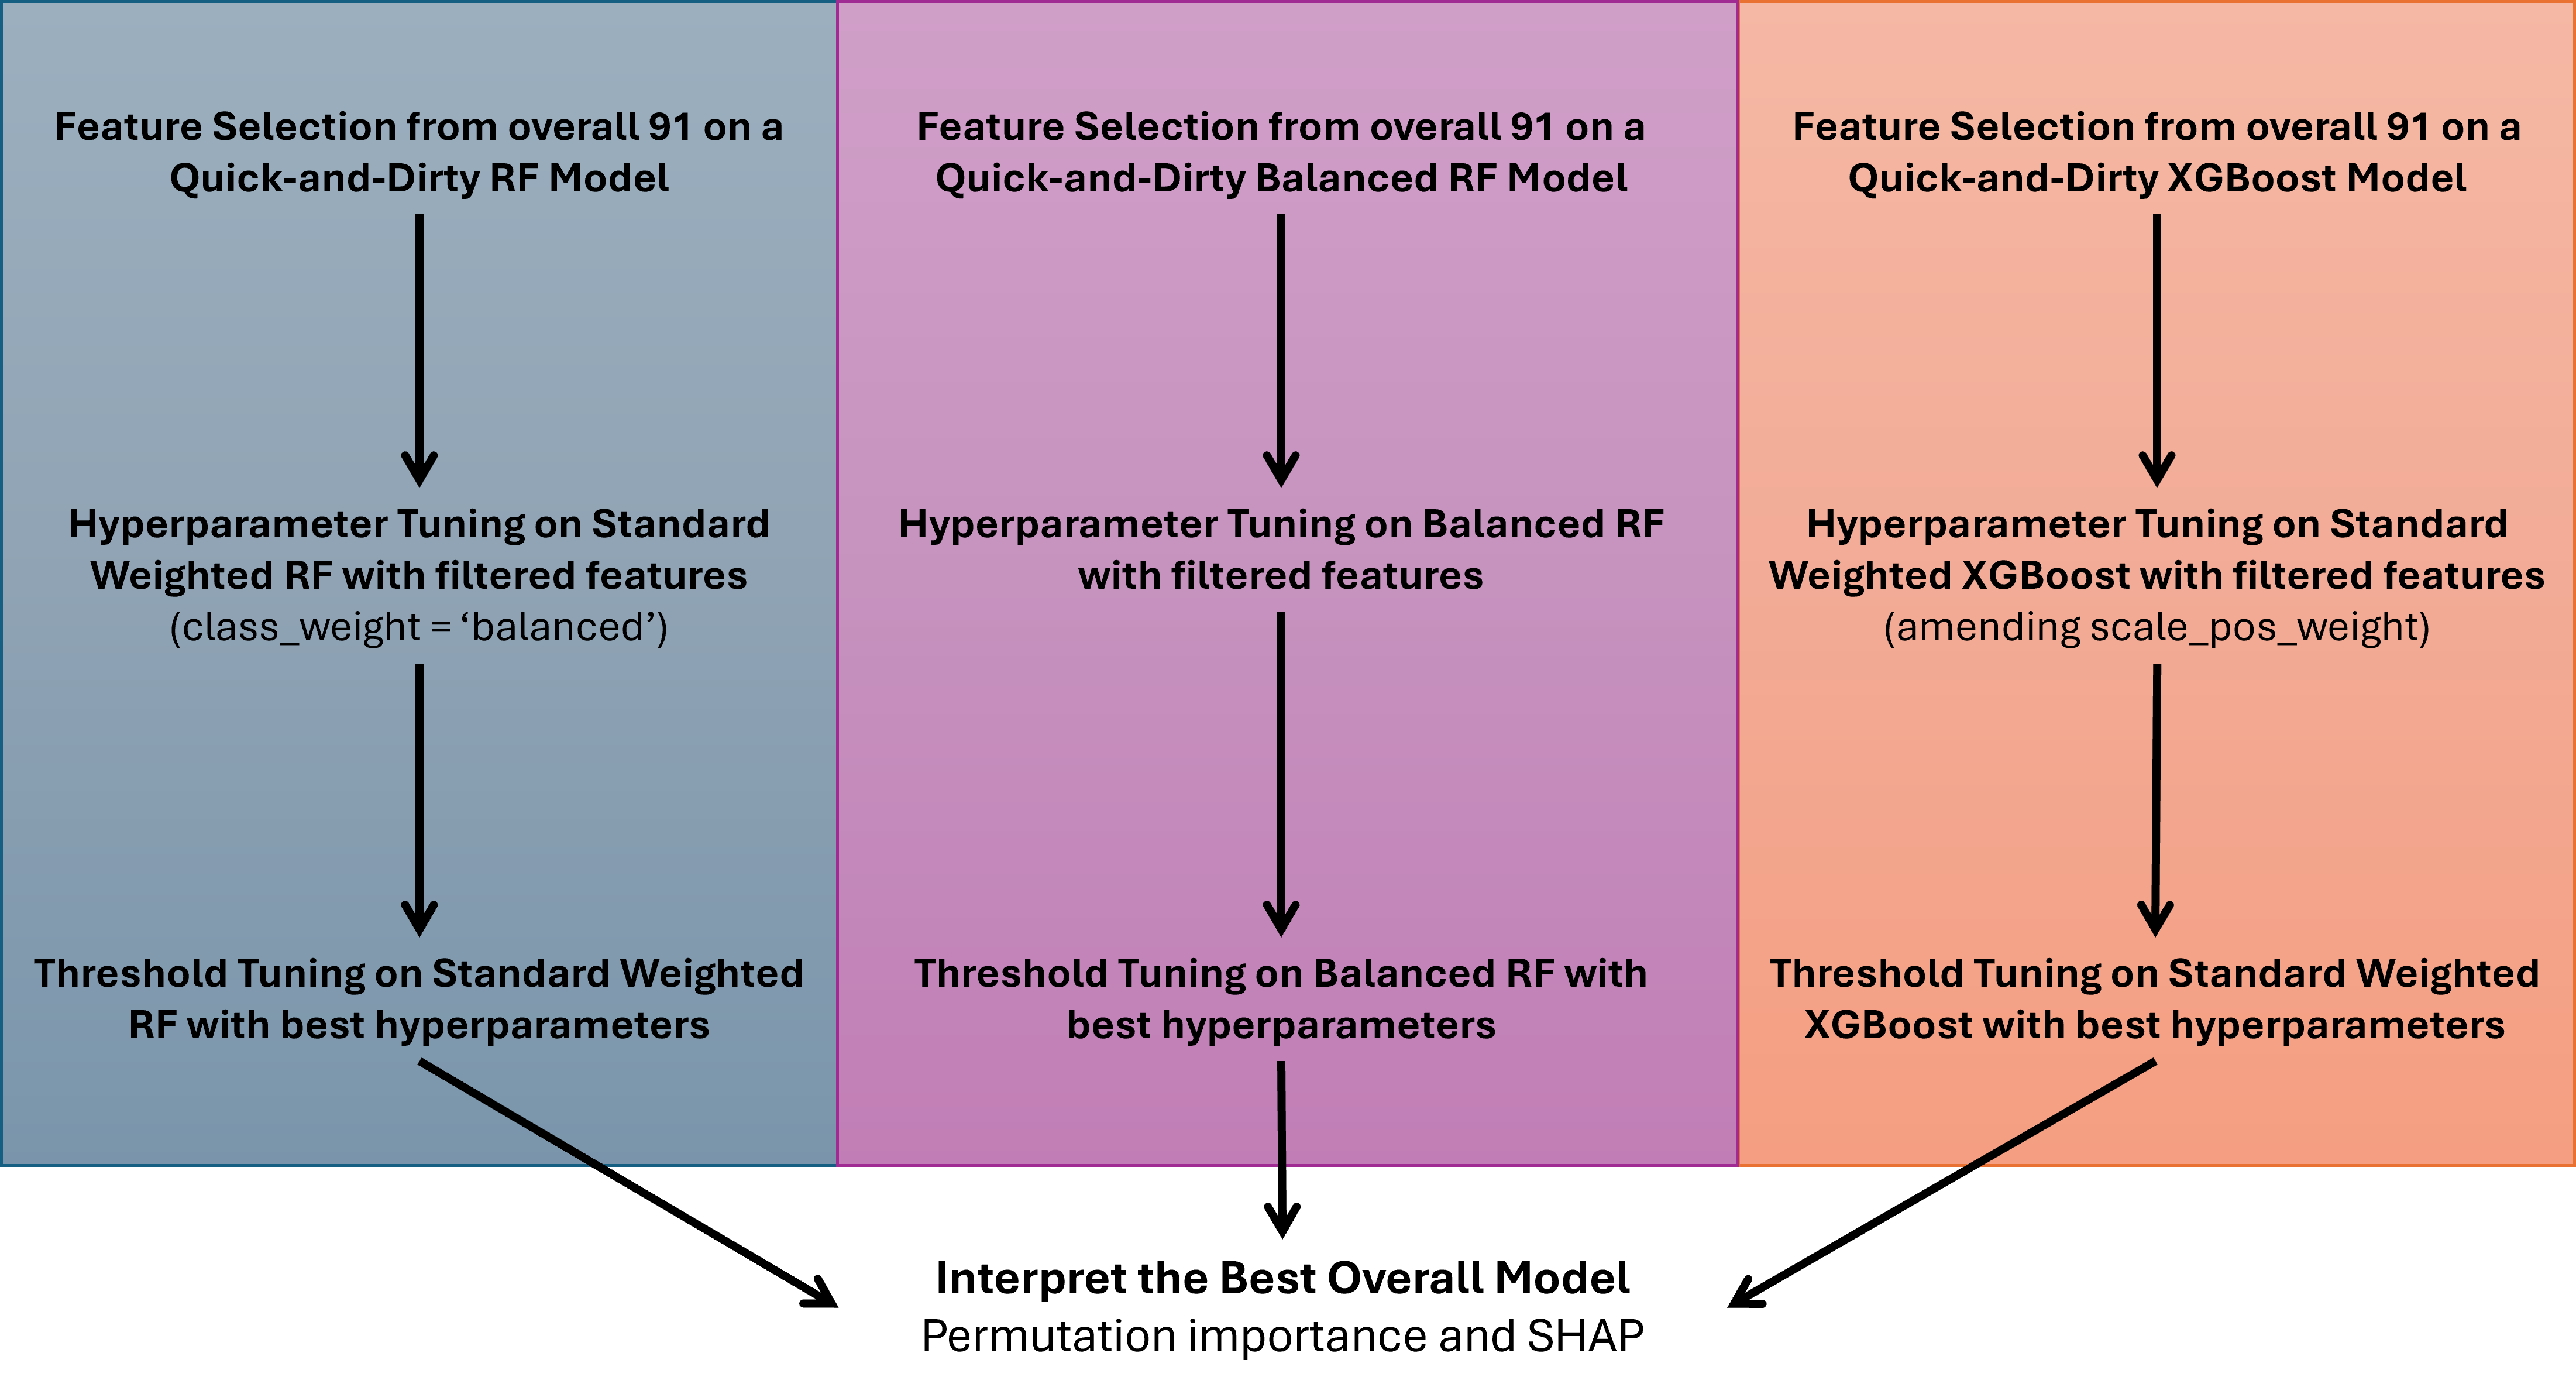

#### 4.1 Initial Common Settings for Random Forest and XGBoost

In [18]:
# Separating full_dataset into X and y
y = full_dataset['casualty_severity']
X = full_dataset.drop(
    columns = 'casualty_severity'
)

# Conducting the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    stratify = y,
    random_state = 42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (18080, 91)
Test shape: (4520, 91)


In [19]:
# Setting the CV split
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

# Setting a custom scorer for MCC to be added into GridSearchCV
mcc = make_scorer(matthews_corrcoef)

# Setting the range for threshold tuning
thresholds = np.arange(0.1, 1.0, 0.05)

#### 4.2.1 Feature Selection on a Simple Weighted RF Model

In [20]:
# Run a quick and dirty RF
base_rf_for_fs = RandomForestClassifier(
    n_estimators = 100,  
    max_depth = 5,       
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

base_rf_for_fs.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [21]:
# Conduct permutation importance on the quick and dirty RF
perm_imp_rf = permutation_importance(
    base_rf_for_fs,
    X_train,
    y_train,
    n_repeats = 10,
    scoring = mcc,
    random_state = 42,
    n_jobs=-1
)

importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_imp_rf.importances_mean,
    'std': perm_imp_rf.importances_std
}).sort_values(
    'importance', 
    ascending = False
)

# Keep features with importance > 0.001 
selected_rf = importance_rf[importance_rf['importance'] > 0.001]['feature'].tolist() 

print(f"Keeping {len(selected_rf)} / {len(X_train.columns)} features")
print(f"Dropped features: {set(X_train.columns) - set(selected_rf)}")

X_train_rf = X_train[selected_rf]
X_test_rf = X_test[selected_rf]

Keeping 26 / 91 features
Dropped features: {'special_conditions_at_site_Roadworks', 'CLT_SEGREG', 'CLT_ADVIS', 'first_point_of_impact_No impact', 'CLT_MANDAT', 'road_type_Roundabout', 'nearby_cycle_lane', 'special_conditions_at_site_Others', 'junction_location_Junction exit', 'just_crashed', 'first_point_of_impact_Offside', 'during_daylight', 'junction_location_Junction approach', 'special_conditions_at_site_None', 'hour_cos', 'road_surface_conditions_Wet/Damp', 'junction_location_Entering from slip road', 'day_cos', 'first_road_class_B', 'speed_limit', 'vehicle_location_restricted_lane_On road', 'hit_object_in_carriageway_None', 'no_light', 'hit_object_in_carriageway_Others', 'hit_offroad', 'journey_purpose_of_driver_To/from work', 'junction_location_Leaving main road', 'month_cos', 'junction_detail_Private driveway', 'CLT_SHARED', 'road_surface_conditions_Dry', 'has_wind', 'first_point_of_impact_Nearside', 'journey_purpose_of_driver_School/school run', 'first_road_class_A', 'carriage

#### 4.2.2 Hyperparameter Tuning on Standard Weighted RF

In [ ]:
# Creating a baseline RF model for CV
baseline_rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

# Establishing the parameter grid for RF
rf_param_grid = {
    'n_estimators': [300],
    'max_depth': [6, 8],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 30],
    'max_features': [0.2, 0.3, 0.4, 'sqrt']
}

In [ ]:
# Conducting GridSearchCV for RF, optimised for MCC
grid_rf = GridSearchCV(
    estimator = baseline_rf_model,
    param_grid = rf_param_grid,
    cv = cv,
    scoring = mcc,
    n_jobs = -1,
    return_train_score = True
)

grid_rf.fit(X_train_rf, y_train)

# Summarising results to show how much overfitting between train and validation sets during CV
results_rf = pd.DataFrame(grid_rf.cv_results_)

summary_cols = [
    'params',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

results_table_rf = (
    results_rf[summary_cols].sort_values(
        'rank_test_score'
    ).reset_index(
        drop = True
    )
)

results_table_rf.head(10)

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 8, 'max_features': 0.4, 'min_sam...",0.291300,0.117243,0.018455,1
1,"{'max_depth': 8, 'max_features': 0.2, 'min_sam...",0.256299,0.115590,0.014024,2
2,"{'max_depth': 8, 'max_features': 0.2, 'min_sam...",0.256299,0.115590,0.014024,2
3,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.256299,0.115590,0.014024,2
4,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.256299,0.115590,0.014024,2
5,"{'max_depth': 8, 'max_features': 0.3, 'min_sam...",0.264773,0.115331,0.019602,6
6,"{'max_depth': 8, 'max_features': 0.3, 'min_sam...",0.264773,0.115331,0.019602,6
7,"{'max_depth': 8, 'max_features': 0.3, 'min_sam...",0.250988,0.115106,0.018263,8
8,"{'max_depth': 8, 'max_features': 0.2, 'min_sam...",0.246339,0.115016,0.019503,9
9,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.246339,0.115016,0.019503,9


In [ ]:
# Applying the best params from GridSearchCV RF on the entire training dataset and hold-out test set, and showing how much overfitting there is
best_rf_params = grid_rf.best_params_
weighted_rf = RandomForestClassifier(
    random_state = 42, 
    class_weight = 'balanced', 
    n_jobs = -1, 
    **best_rf_params
)
weighted_rf.fit(X_train_rf, y_train)

print("=== TRAINING Stats on Weighted RF with Best Hyperparameters ===")
print(f"MCC: {matthews_corrcoef(y_train, weighted_rf.predict(X_train_rf)):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, weighted_rf.predict(X_train_rf)):.3f}")
print(f"ROC AUC: {roc_auc_score(y_train, weighted_rf.predict_proba(X_train_rf)[:, 1]):.3f}")

mcc_rf = matthews_corrcoef(y_test, weighted_rf.predict(X_test_rf))
bal_acc_rf = balanced_accuracy_score(y_test, weighted_rf.predict(X_test_rf))
roc_auc_rf = roc_auc_score(y_test, weighted_rf.predict_proba(X_test_rf)[:, 1])
accuracy_rf = accuracy_score(y_test, weighted_rf.predict(X_test_rf))

print("=== TESTING Stats on Weighted RF with Best Hyperparameters ===")
print(f"MCC: {mcc_rf:.3f}")
print(f"Balanced Accuracy: {bal_acc_rf:.3f}")
print(f"ROC AUC: {roc_auc_rf:.3f}")
print(f"Accuracy: {accuracy_rf:.3f}")

=== TRAINING Stats on Weighted RF with Best Hyperparameters ===
MCC: 0.265
Balanced Accuracy: 0.655
ROC AUC: 0.722
=== TESTING Stats on Weighted RF with Best Hyperparameters ===
MCC: 0.132
Balanced Accuracy: 0.577
ROC AUC: 0.609
Accuracy: 0.655


#### 4.2.3 Threshold Tuning on Standard Weighted RF Model

In [ ]:
# Conducting threshold tuning on the best hyperparams for the RF model
results_rf_tuning = []

for t in thresholds:
    # Convert probabilities to binary predictions using this threshold
    y_pred_rf_tune = (weighted_rf.predict_proba(X_test_rf)[:, 1] >= t).astype(int)
    
    results_rf_tuning.append({
        'threshold': t,
        'mcc': matthews_corrcoef(y_test, y_pred_rf_tune),
        'bal_acc': balanced_accuracy_score(y_test, y_pred_rf_tune),
        'accuracy': accuracy_score(y_test, y_pred_rf_tune),
    })

results_rf_tuning = pd.DataFrame(results_rf_tuning)

# Finding the threshold that maximizes MCC
best_idx_rf = results_rf_tuning['mcc'].idxmax()
best_threshold_rf = results_rf_tuning.loc[best_idx_rf, 'threshold']
best_mcc_rf = results_rf_tuning.loc[best_idx_rf, 'mcc']
best_bal_acc_rf = results_rf_tuning.loc[best_idx_rf, 'bal_acc']
best_acc_rf = results_rf_tuning.loc[best_idx_rf, 'accuracy']

# Get MCC at default threshold (0.50)
default_idx_rf = (np.abs(results_rf_tuning['threshold'] - 0.50)).argmin()
default_mcc_rf = results_rf_tuning.loc[default_idx_rf, 'mcc']

# Calculate improvement
improvement_rf = best_mcc_rf - default_mcc_rf

print(f"\nDefault threshold (0.50):  MCC = {default_mcc_rf:.4f}")
print(f"Optimal threshold ({best_threshold_rf:.2f}): MCC = {best_mcc_rf:.4f}")
print(f"Improvement:               ΔMCC = {improvement_rf:+.4f}")


Default threshold (0.50):  MCC = 0.1315
Optimal threshold (0.50): MCC = 0.1315
Improvement:               ΔMCC = +0.0000


In [ ]:
# Select the best threshold between pre- and post-tuning, as well as the associated scores
if improvement_rf > 0:
    best_rf_mcc = best_mcc_rf
    best_rf_bal_acc = best_bal_acc_rf
    best_rf_roc_auc = roc_auc_rf # ROC AUC is threshold independent, this won't change
    best_rf_accuracy = best_acc_rf
    best_rf_threshold = best_threshold_rf
else:  
    # keep to the one derived from before Threshold Tuning
    best_rf_mcc = mcc_rf
    best_rf_bal_acc = bal_acc_rf
    best_rf_roc_auc = roc_auc_rf
    best_rf_accuracy = best_acc_rf
    best_rf_threshold = 0.50

#### 4.3.1 Feature Selection on a Simple Balanced RF Model

In [27]:
# Run a quick and dirty BRF
base_brf_for_fs = BalancedRandomForestClassifier(
    n_estimators = 100,  
    max_depth = 5,       
    random_state = 42,
    n_jobs = -1
)

base_brf_for_fs.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [28]:
# Conduct permutation importance on the quick and dirty BRF
perm_imp_brf = permutation_importance(
    base_brf_for_fs,
    X_train,
    y_train,
    n_repeats = 10,
    scoring = mcc,
    random_state = 42,
    n_jobs=-1
)

importance_brf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_imp_brf.importances_mean,
    'std': perm_imp_brf.importances_std
}).sort_values(
    'importance', 
    ascending = False
)

# Keep features with importance > 0.001 
selected_brf = importance_brf[importance_brf['importance'] > 0.001]['feature'].tolist() 

print(f"Keeping {len(selected_brf)} / {len(X_train.columns)} features")
print(f"Dropped features: {set(X_train.columns) - set(selected_brf)}")

X_train_brf = X_train[selected_brf]
X_test_brf = X_test[selected_brf]

Keeping 26 / 91 features
Dropped features: {'special_conditions_at_site_Roadworks', 'CLT_SEGREG', 'CLT_ADVIS', 'hit_object_in_carriageway_Kerb', 'first_point_of_impact_No impact', 'CLT_MANDAT', 'is_tfl_managed', 'month_sin', 'road_type_Roundabout', 'nearby_cycle_lane', 'special_conditions_at_site_Others', 'junction_location_Junction exit', 'just_crashed', 'first_point_of_impact_Offside', 'during_daylight', 'junction_location_Junction approach', 'special_conditions_at_site_None', 'hour_cos', 'road_surface_conditions_Wet/Damp', 'junction_location_Entering from slip road', 'first_road_class_B', 'vehicle_location_restricted_lane_On road', 'speed_limit', 'no_light', 'hit_object_in_carriageway_Others', 'hit_offroad', 'journey_purpose_of_driver_To/from work', 'junction_location_Leaving main road', 'junction_detail_Private driveway', 'CLT_SHARED', 'has_wind', 'first_point_of_impact_Nearside', 'journey_purpose_of_driver_School/school run', 'has_heavy_vehicles', 'carriageway_hazards_Others', 'fi

#### 4.3.2 Hyperparameter Tuning on Balanced RF Model

In [ ]:
# Creating a baseline BRF model for CV
baseline_brf_model = BalancedRandomForestClassifier(
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

# Establishing the parameter grid for BRF
brf_param_grid = {
    'n_estimators': [700, 800],
    'max_depth': [None],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf': [2, 3],
    'max_features': ['log2']
}

In [ ]:
# Conducting GridSearchCV for BRF, optimised for MCC
grid_brf = GridSearchCV(
    estimator = baseline_brf_model,
    param_grid = brf_param_grid,
    cv = cv,
    scoring = mcc,
    n_jobs = -1,
    return_train_score = True
)

grid_brf.fit(X_train_brf, y_train)

# Summarising results to show how much overfitting between train and validation sets during CV
results_brf = pd.DataFrame(grid_brf.cv_results_)

summary_cols = [
    'params',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

results_table_brf = (
    results_brf[summary_cols].sort_values(
        'rank_test_score'
    ).reset_index(
        drop = True
    )
)

results_table_brf.head(10)

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': None, 'max_features': 'log2', 'm...",0.474683,0.153348,0.013584,1
1,"{'max_depth': None, 'max_features': 'log2', 'm...",0.474499,0.152098,0.013049,2
2,"{'max_depth': None, 'max_features': 'log2', 'm...",0.533779,0.148440,0.018909,3
3,"{'max_depth': None, 'max_features': 'log2', 'm...",0.450448,0.147669,0.012155,4
4,"{'max_depth': None, 'max_features': 'log2', 'm...",0.450651,0.147364,0.013863,5
5,"{'max_depth': None, 'max_features': 'log2', 'm...",0.533379,0.147038,0.018764,6
6,"{'max_depth': None, 'max_features': 'log2', 'm...",0.429837,0.141967,0.010077,7
7,"{'max_depth': None, 'max_features': 'log2', 'm...",0.430046,0.140879,0.010877,8
8,"{'max_depth': None, 'max_features': 'log2', 'm...",0.409882,0.138993,0.012335,9
9,"{'max_depth': None, 'max_features': 'log2', 'm...",0.410046,0.138602,0.012995,10


In [ ]:
# Applying the best params from GridSearchCV BRF on the entire training dataset and hold-out test set, and showing how much overfitting there is
best_brf_params = grid_brf.best_params_
weighted_brf = BalancedRandomForestClassifier(
    random_state = 42, 
    class_weight = 'balanced', 
    n_jobs = -1, 
    **best_brf_params
)
weighted_brf.fit(X_train_brf, y_train)

print("=== TRAINING Stats on Weighted BRF with Best Hyperparameters ===")
print(f"MCC: {matthews_corrcoef(y_train, weighted_brf.predict(X_train_brf)):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, weighted_brf.predict(X_train_brf)):.3f}")
print(f"ROC AUC: {roc_auc_score(y_train, weighted_brf.predict_proba(X_train_brf)[:, 1]):.3f}")

mcc_brf = matthews_corrcoef(y_test, weighted_brf.predict(X_test_brf))
bal_acc_brf = balanced_accuracy_score(y_test, weighted_brf.predict(X_test_brf))
roc_auc_brf = roc_auc_score(y_test, weighted_brf.predict_proba(X_test_brf)[:, 1])
accuracy_brf = accuracy_score(y_test, weighted_brf.predict(X_test_brf))

print("=== TESTING Stats on Weighted BRF with Best Hyperparameters ===")
print(f"MCC: {mcc_brf:.3f}")
print(f"Balanced Accuracy: {bal_acc_brf:.3f}")
print(f"ROC AUC: {roc_auc_brf:.3f}")
print(f"Accuracy: {accuracy_brf:.3f}")

=== TRAINING Stats on Weighted BRF with Best Hyperparameters ===
MCC: 0.474
Balanced Accuracy: 0.796
ROC AUC: 0.992
=== TESTING Stats on Weighted BRF with Best Hyperparameters ===
MCC: 0.157
Balanced Accuracy: 0.597
ROC AUC: 0.639
Accuracy: 0.508


#### 4.3.3 Threshold Tuning on Balanced RF Model

In [ ]:
# Conducting threshold tuning on the best hyperparams for the BRF model
results_brf_tuning = []

for t in thresholds:
    # Convert probabilities to binary predictions using this threshold
    y_pred_brf_tune = (weighted_brf.predict_proba(X_test_brf)[:, 1] >= t).astype(int)
    
    results_brf_tuning.append({
        'threshold': t,
        'mcc': matthews_corrcoef(y_test, y_pred_brf_tune),
        'bal_acc': balanced_accuracy_score(y_test, y_pred_brf_tune),
        'accuracy': accuracy_score(y_test, y_pred_brf_tune),
    })

results_brf_tuning = pd.DataFrame(results_brf_tuning)

# Find the threshold that maximizes MCC
best_idx_brf = results_brf_tuning['mcc'].idxmax()
best_threshold_brf = results_brf_tuning.loc[best_idx_brf, 'threshold']
best_mcc_brf = results_brf_tuning.loc[best_idx_brf, 'mcc']
best_bal_acc_brf = results_brf_tuning.loc[best_idx_brf, 'bal_acc']
best_acc_brf = results_brf_tuning.loc[best_idx_brf, 'accuracy']

# Get MCC at default threshold (0.50)
default_idx_brf = (np.abs(results_brf_tuning['threshold'] - 0.50)).argmin()
default_mcc_brf = results_brf_tuning.loc[default_idx_brf, 'mcc']

# Calculate improvement
improvement_brf = best_mcc_brf - default_mcc_brf

print(f"\nDefault threshold (0.50):  MCC = {default_mcc_brf:.4f}")
print(f"Optimal threshold ({best_threshold_brf:.2f}): MCC = {best_mcc_brf:.4f}")
print(f"Improvement:               ΔMCC = {improvement_brf:+.4f}")


Default threshold (0.50):  MCC = 0.1572
Optimal threshold (0.60): MCC = 0.1646
Improvement:               ΔMCC = +0.0074


In [ ]:
# Select the best threshold between pre- and post-tuning, as well as the associated scores
if improvement_brf > 0:
    best_brf_mcc = best_mcc_brf
    best_brf_bal_acc = best_bal_acc_brf
    best_brf_roc_auc = roc_auc_brf # ROC AUC is threshold independent, this won't change
    best_brf_accuracy = best_acc_brf
    best_brf_threshold = best_threshold_brf
else:  
    # keep to the one derived from before Threshold Tuning
    best_brf_mcc = mcc_brf
    best_brf_bal_acc = bal_acc_brf
    best_brf_roc_auc = roc_auc_brf
    best_brf_accuracy = accuracy_brf
    best_brf_threshold = 0.50

#### 4.4.1 Feature Selection on a Simple Weighted XGB Model

In [34]:
# Setting up a quick scale_pos_weight value so that Baseline XGB can rebalance the imbalanced KSI:Slight ratio
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

# Run a quick and dirty XGB
base_xb_for_fs = XGBClassifier(
    n_estimators = 100,
    max_depth = 3,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight_value,
    random_state = 42,
    n_jobs = -1
)

base_xb_for_fs.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
# Conduct permutation importance on the quick and dirty XGB
perm_imp_xb = permutation_importance(
    base_xb_for_fs,
    X_train,
    y_train,
    n_repeats = 10,
    scoring = mcc,
    random_state = 42,
    n_jobs = -1
)

importance_xb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_imp_xb.importances_mean,
    'std': perm_imp_xb.importances_std
}).sort_values(
    'importance', 
    ascending = False
)

# Keep features with importance > 0.001 
selected_xb = importance_xb[importance_xb['importance'] > 0.001]['feature'].tolist() 

print(f"Keeping {len(selected_xb)} / {len(X_train.columns)} features")
print(f"Dropped features: {set(X_train.columns) - set(selected_xb)}")

X_train_xb = X_train[selected_xb]
X_test_xb = X_test[selected_xb]

Keeping 34 / 91 features
Dropped features: {'special_conditions_at_site_Roadworks', 'CLT_SEGREG', 'CLT_ADVIS', 'first_point_of_impact_No impact', 'junction_detail_Not at junction', 'CLT_MANDAT', 'month_sin', 'road_type_Roundabout', 'nearby_cycle_lane', 'special_conditions_at_site_Others', 'junction_location_Junction exit', 'just_crashed', 'first_point_of_impact_Offside', 'during_daylight', 'skidded', 'junction_location_Junction approach', 'special_conditions_at_site_None', 'road_surface_conditions_Wet/Damp', 'junction_location_Entering from slip road', 'day_cos', 'first_road_class_B', 'speed_limit', 'no_light', 'hit_object_in_carriageway_None', 'fine_weather', 'hit_object_in_carriageway_Others', 'hit_offroad', 'junction_location_Leaving main road', 'junction_detail_Private driveway', 'CLT_SHARED', 'road_surface_conditions_Dry', 'has_wind', 'journey_purpose_of_driver_School/school run', 'carriageway_hazards_None', 'carriageway_hazards_Others', 'road_type_One way street', 'overturned', '

#### 4.4.2 Hyperparameter Tuning on Standard Weighted XGB Model

In [ ]:
# Creating a  baseline XGB model for CV
baseline_xb_model = XGBClassifier(
    scale_pos_weight = scale_pos_weight_value,
    random_state = 42,
    n_jobs = 1,
    device = 'cuda'
)

# Establishing the parameter grid for XGB
xb_param_grid = {
    'n_estimators': [250, 300],
    'max_depth': [2, 3],
    'learning_rate': [0.05, 0.07, 0.1],
    'subsample': [0.9, 1.0],
    'colsample_bytree': [0.75, 0.85],
    'min_child_weight': [3, 4, 5]
}

In [ ]:
# Conducting GridSearchCV for XGB, optimised for MCC
grid_xb = GridSearchCV(
    estimator = baseline_xb_model,
    param_grid = xb_param_grid,
    cv = cv,
    scoring = mcc,
    n_jobs = 2,
    return_train_score = True
)

grid_xb.fit(X_train_xb, y_train)

# Summarising results to show how much overfitting between train and validation sets during CV
results_xb = pd.DataFrame(grid_xb.cv_results_)

summary_cols = [
    'params',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

results_table_xb = (
    results_xb[summary_cols].sort_values(
        'rank_test_score'
    ).reset_index(
        drop = True
    )
)

results_table_xb.head(10)

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.230828,0.188912,0.018521,1
1,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.230859,0.187463,0.017340,2
2,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.236407,0.187094,0.018680,3
3,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.270405,0.186804,0.012806,4
4,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.236519,0.186659,0.016160,5
5,"{'colsample_bytree': 0.75, 'learning_rate': 0....",0.240550,0.186094,0.016852,6
6,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.220668,0.185521,0.012752,7
7,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.226154,0.185390,0.017297,8
8,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.225443,0.184983,0.016217,9
9,"{'colsample_bytree': 0.85, 'learning_rate': 0....",0.268622,0.184884,0.011917,10


In [ ]:
# Applying the best params from GridSearchCV XGB on the entire training dataset and hold-out test set, and showing how much overfitting there is
best_xb_params = grid_xb.best_params_
weighted_xb = XGBClassifier(
    scale_pos_weight = scale_pos_weight_value,
    random_state = 42, 
    n_jobs = -1,
    **best_xb_params
)
weighted_xb.fit(X_train_xb, y_train)

print("=== TRAINING Stats on Weighted XGB with Best Hyperparameters ===")
print(f"MCC: {matthews_corrcoef(y_train, weighted_xb.predict(X_train_xb)):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, weighted_xb.predict(X_train_xb)):.3f}")
print(f"ROC AUC: {roc_auc_score(y_train, weighted_xb.predict_proba(X_train_xb)[:, 1]):.3f}")

mcc_xb = matthews_corrcoef(y_test, weighted_xb.predict(X_test_xb))
bal_acc_xb = balanced_accuracy_score(y_test, weighted_xb.predict(X_test_xb))
roc_auc_xb = roc_auc_score(y_test, weighted_xb.predict_proba(X_test_xb)[:, 1])
accuracy_xb = accuracy_score(y_test, weighted_xb.predict(X_test_xb))

print("=== TESTING Stats on Weighted XGB with Best Hyperparameters ===")
print(f"MCC: {mcc_xb:.3f}")
print(f"Balanced Accuracy: {bal_acc_xb:.3f}")
print(f"ROC AUC: {roc_auc_xb:.3f}")
print(f"Accuracy: {accuracy_xb:.3f}")

=== TRAINING Stats on Weighted XGB with Best Hyperparameters ===
MCC: 0.222
Balanced Accuracy: 0.638
ROC AUC: 0.690
=== TESTING Stats on Weighted XGB with Best Hyperparameters ===
MCC: 0.181
Balanced Accuracy: 0.613
ROC AUC: 0.657
Accuracy: 0.607


#### 4.4.3 Threshold Tuning on Standard Weighted XGB Model

In [ ]:
# Conducting threshold tuning on the best hyperparams for the XGB model
thresholds = np.arange(0.1, 1.0, 0.05)
results_xb_tuning = []

for t in thresholds:
    # Convert probabilities to binary predictions using this threshold
    y_pred_xb_tune = (weighted_xb.predict_proba(X_test_xb)[:, 1] >= t).astype(int)
    
    results_xb_tuning.append({
        'threshold': t,
        'mcc': matthews_corrcoef(y_test, y_pred_xb_tune),
        'bal_acc': balanced_accuracy_score(y_test, y_pred_xb_tune),
        'accuracy': accuracy_score(y_test, y_pred_xb_tune),
    })

results_xb_tuning = pd.DataFrame(results_xb_tuning)

# Find the threshold that maximizes MCC
best_idx_xb = results_xb_tuning['mcc'].idxmax()
best_threshold_xb = results_xb_tuning.loc[best_idx_xb, 'threshold']
best_mcc_xb = results_xb_tuning.loc[best_idx_xb, 'mcc']
best_bal_acc_xb = results_xb_tuning.loc[best_idx_xb, 'bal_acc']
best_acc_xb = results_xb_tuning.loc[best_idx_xb, 'accuracy']

# Get MCC at default threshold (0.50)
default_idx_xb = (np.abs(results_xb_tuning['threshold'] - 0.50)).argmin()
default_mcc_xb = results_xb_tuning.loc[default_idx_xb, 'mcc']

# Calculate improvement
improvement_xb = best_mcc_xb - default_mcc_xb

print(f"\nDefault threshold (0.50):  MCC = {default_mcc_xb:.4f}")
print(f"Optimal threshold ({best_threshold_xb:.2f}): MCC = {best_mcc_xb:.4f}")
print(f"Improvement:               ΔMCC = {improvement_xb:+.4f}")


Default threshold (0.50):  MCC = 0.1811
Optimal threshold (0.55): MCC = 0.1818
Improvement:               ΔMCC = +0.0008


In [ ]:
# Select the best threshold between pre- and post-tuning, as well as the associated scores
if improvement_xb > 0:
    best_xb_mcc = best_mcc_xb
    best_xb_bal_acc = best_bal_acc_xb
    best_xb_roc_auc = roc_auc_xb # ROC AUC is threshold independent, this won't change
    best_xb_accuracy = best_acc_xb
    best_xb_threshold = best_threshold_xb
else:  
    # keep to the one derived from before Threshold Tuning
    best_xb_mcc = mcc_xb
    best_xb_bal_acc = bal_acc_xb
    best_xb_roc_auc = roc_auc_xb
    best_xb_accuracy = accuracy_xb
    best_xb_threshold = 0.50

#### 4.5 Which Algorithm Wins? and Model Interpretation

In [ ]:
# Comparing the best models from each algorithm in a final showdown table
final_showdown = pd.DataFrame([
    {
        'Algorithm': 'Random Forest',
        'Strategy': 'Standard Weighted RF',
        'MCC': best_rf_mcc,
        'Balanced Accuracy': best_rf_bal_acc,
        'ROC_AUC': best_rf_roc_auc,
        'Accuracy': best_rf_accuracy,
        'Threshold': best_rf_threshold
    },
    {
        'Algorithm': 'Balanced Random Forest',
        'Strategy': 'Balanced RF',
        'MCC': best_brf_mcc,
        'Balanced Accuracy': best_brf_bal_acc,
        'ROC_AUC': best_brf_roc_auc,
        'Accuracy': best_brf_accuracy,
        'Threshold': best_brf_threshold
    },
    {
        'Algorithm': 'XGBoost',
        'Strategy': 'Standard Weighted XGBoost',
        'MCC': best_xb_mcc,
        'Balanced Accuracy': best_xb_bal_acc,
        'ROC_AUC': best_xb_roc_auc,
        'Accuracy': best_xb_accuracy,
        'Threshold': best_xb_threshold
    }
])

final_showdown

,Algorithm,Strategy,MCC,Balanced Accuracy,ROC_AUC,Accuracy,Threshold
0,Random Forest,Standard Weighted RF,0.131513,0.577075,0.609365,0.655310,0.50
1,Balanced Random Forest,Balanced RF,0.164558,0.596373,0.638878,0.668142,0.60
2,XGBoost,Standard Weighted XGBoost,0.181844,0.605931,0.657061,0.678097,0.55


In [42]:
# Picking the best algorithm out of all
best_algo = final_showdown.loc[final_showdown['MCC'].idxmax()]

if best_algo['Algorithm'] == 'Random Forest':
    best_model = weighted_rf
    best_X_test = X_test_rf
elif best_algo['Algorithm'] == 'Balanced Random Forest':
    best_model = weighted_brf
    best_X_test = X_test_brf
else:
    best_model = weighted_xb
    best_X_test = X_test_xb

print(f'Precision: {precision_score(y_test, best_model.predict(best_X_test)):.3f}')
print(f'Recall: {recall_score(y_test, best_model.predict(best_X_test)):.3f}')
print(f'F1-Score: {f1_score(y_test, best_model.predict(best_X_test)):.3f}')

Precision: 0.280
Recall: 0.622
F1-Score: 0.386


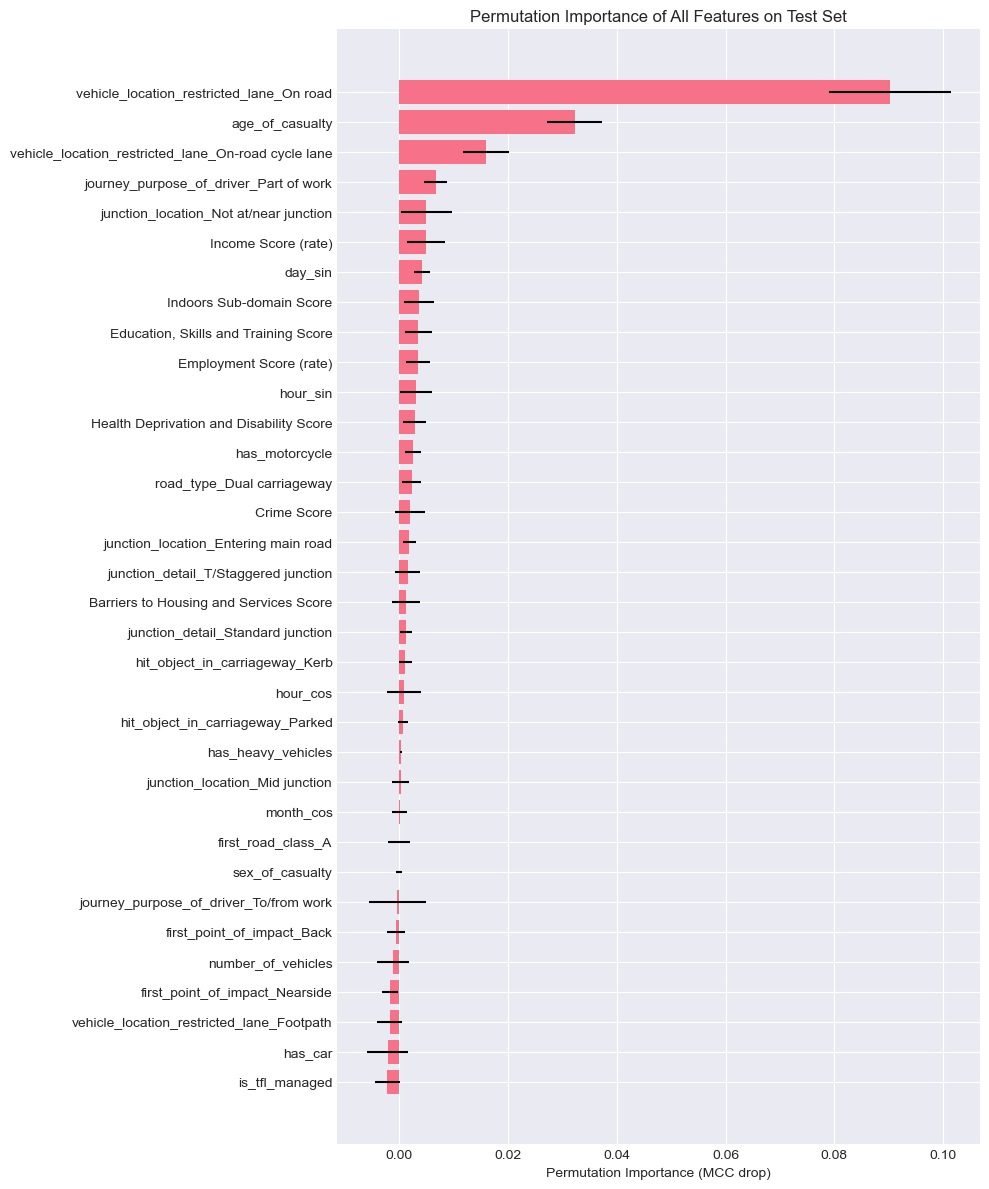

In [ ]:
# Calculate permutation importance on TEST set based on the best model and its associated best_X_test, using MCC as the scoring metric
perm_importance = permutation_importance(
    best_model, 
    best_X_test, 
    y_test,
    n_repeats = 10,
    random_state = 42,
    scoring = mcc,
    n_jobs = 1
)

perm_importance_df = pd.DataFrame({
    'feature': best_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Plot with error bars
plt.figure(figsize=(10, 12))
plt.barh(
    range(len(perm_importance_df)), 
    perm_importance_df['importance_mean'],
    xerr=perm_importance_df['importance_std']  # To show the variability of importance across permutations
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df['feature'])
plt.xlabel('Permutation Importance (MCC drop)')
plt.title('Permutation Importance of All Features on Test Set')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
# Create SHAP explainer
# normal TreeExplainer did not work for XGBoost
# so KernelExplainer is used instead, which is model-agnostic but more computationally intensive

# Take a subset of 1000 rows
X_test_subset = shap.sample(best_X_test, 1000, random_state=42)

# Create SHAP explainer (background can stay small like 100)
explainer = shap.KernelExplainer(
    lambda x: best_model.predict_proba(x)[:, 1],
    shap.sample(best_X_test, 100)
)

# Compute SHAP values ONLY for subset
shap_values = explainer.shap_values(X_test_subset)

print("=== SHAP Summary ===")
print(f"SHAP values shape: {shap_values.shape}")

  0%|          | 0/1000 [00:00<?, ?it/s]

=== SHAP Summary ===
SHAP values shape: (1000, 34)


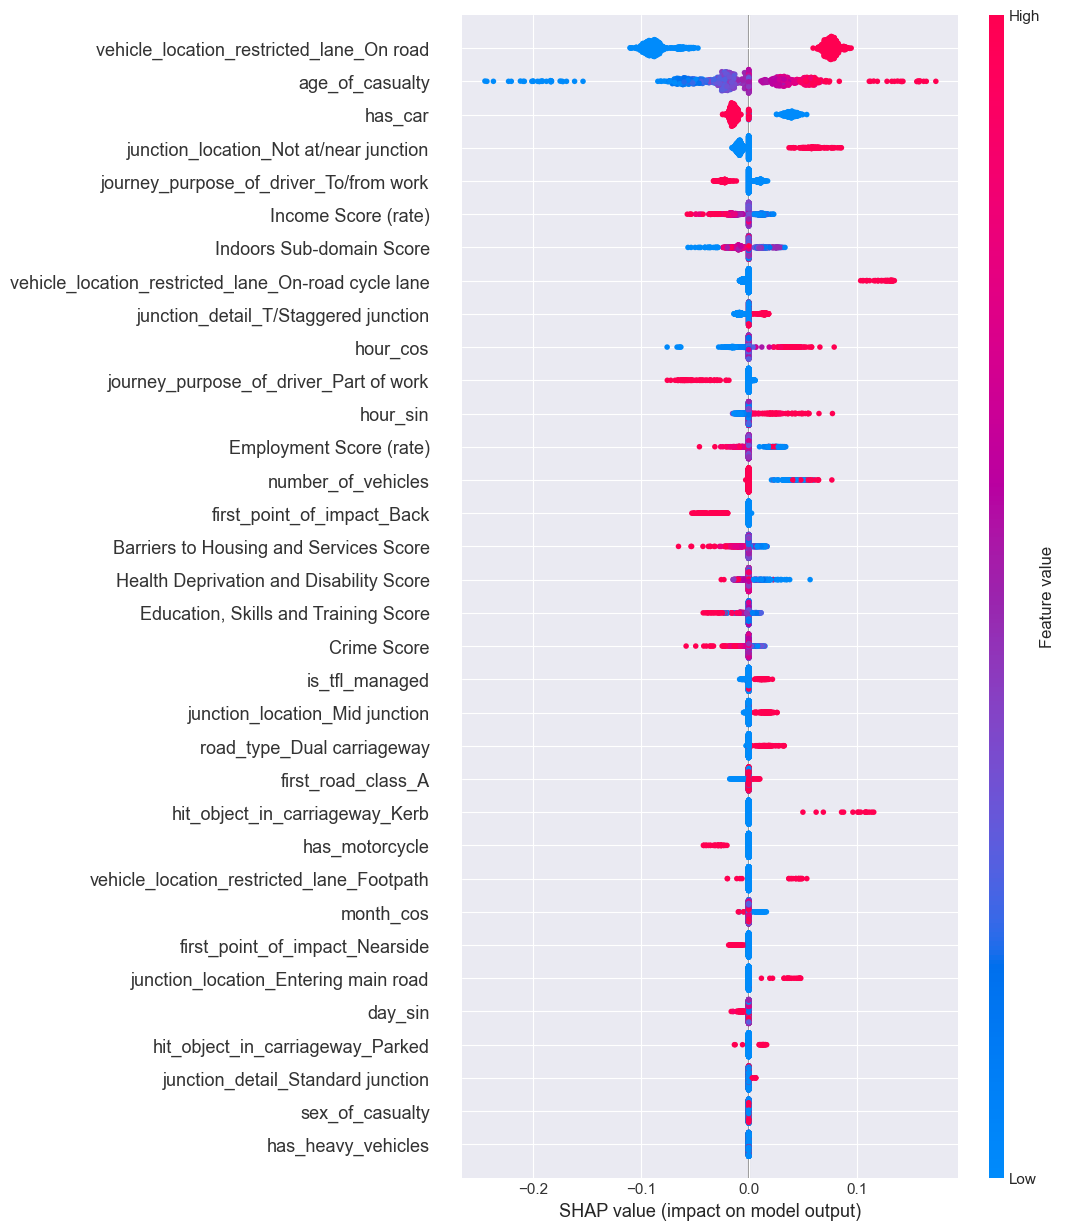

In [45]:
# Create explanation object using subset
shap_explanation_subset = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_subset.values,
    feature_names=X_test_subset.columns.tolist()
)

# Plot beeswarm
shap.plots.beeswarm(
    shap_explanation_subset,
    max_display=len(X_test_subset.columns)
)

In [46]:
end_time = time.perf_counter()
total_time = end_time - start_time

print(f"Total runtime: {total_time/60:.2f} minutes")

Total runtime: 16.74 minutes


## Results and Discussion

**On Feature Selection**  

Weighted Random Forest and Balanced Random Forest are more aggressive in filtering features than Weighted XGBoost, as the former keeps only about 29% of all 91 features while the latter keeps about 37%. 

Across the three algorithms, they agree that the following factors are NOT important in determining cyclist casualty severity and are therefore filtered out:

*Environmental Features*
- light conditions
- weather conditions
- any special conditions or hazards on the road
- cyclist's exact position relative to the junction, if any
- hitting objects off the road, if any

*Infrastructural Features*
- cycle lane characteristics

---

**On Hyperparameter Tuning via Cross-Validation**  

There are already signs that XGBoost would be the more suitable algorithm than either Random Forests. This is because XGBoost on its best hyperparameters produced a much higher mean CV MCC score of 0.189, with a standard deviation of 0.0185. In contrast, Standard Weighted RF on its best hyperparameters produced a mean CV MCC score of 0.117 with a standard deviation of 0.0185, while Balanced RF on its best hyperparameters produced a mean CV MCC score of 0.153 with a standard deviation of 0.0136.

This resulted in a higher hold-out test set statistics for XGBoost vis-a-vis both Random Forests:
- *MCC*: 0.132 (RF) vs 0.157 (BRF) vs **0.181 (XGB)**
- *Balanced Accuracy*: 0.609 (RF) vs 0.597 (BRF) vs **0.613 (XGB)**
- *ROC AUC*: 0.609 (RF) vs 0.639 (BRF) vs **0.657 (XGB)**
- *Accuracy*: **0.655 (RF)** vs 0.508 (BRF) vs 0.607 (XGB)

This could indicate XGBoost's ability to recognise more subtle patterns because it builds trees one at a time with the intention to minimise class-weighted loss, in comparison to Random Forest's aggregation of decisions over a lot of trees created at once that would not be able to do so. 

Additionally, it is also important to note that Balanced RF saw the most extreme cases of overfitting in comparison to Standard Weighted RF and Standard Weighted XGBoost. This could suggest that limiting samples of the majority class with the specific intention to match the bootstrapped amount of the minority class may have resulted in loss of data that could have been helpful in making more accurate predictions. This further validates the original decision to not explore further imbalance strategies like SMOTE or ADASYN. 

---

**On Threshold Tuning**

When undergoing threshold tuning, Standard Weighted RF found that its optimal threshold remained 0.5, thus no change in values.

Meanwhile, Balanced RF found that its optimal threshold is up to 0.6, but with a marginal improvement in MCC score by 0.0074.

Standard Weighted XGBoost also saw an improvement by tuning the threshold up to 0.55, albeit only marginally by 0.0008 in the MCC score.

This suggests that in this instance of attempting to predict cyclist casualty severity, the earlier decision to rebalance the class weights through class_weights in Standard Weighted RF and scale_pos_weights in Standard Weighted XGBoost has done most of the heavy lifting to address the 4:1 Slight - KSI imbalance ratio. In contrast, due to Balanced RF randomly limiting the majority class, it has created a different distribution of features that requires more threshold tuning in order to achieve more accurate predictions, thus the threshold is 0.1 higher than default and the improvements in MCC score is more than XGBoost.

---

**Final Output and Interpretation**

After comparing all three models with their best hyperparameters and thresholds, the best model is the **Standard Weighted XGBoost Model**, which, when threshold is set at 0.55, has:
- MCC score of 0.182, 
- Balanced Accuracy score of 0.606,
- Accuracy score of 0.678, and
- ROC AUC score is at 0.657.

However, with a recall of 0.622 and precision of 0.288, it is likely that the combination of optimising for MCC and a fairly aggressive rebalancing weights of the minority-majority classes has resulted in a model that has been optimised to identify KSI cases instead.

Out of the 34 features that Standard Weighted XGBoost kept after feature selection, only 25 had positive permutation importance (up until month_cos) while the remaining nine have slight negative importance. The three most important features are, in descending order: being on the normal lane during collision, age of cyclist, and being in an on-road cycle lane during collision. Meanwhile, SHAP value distributions somewhat corroborate the permutation importance rankings, as the top two features match.

**Age of casualty** shows a clear positive relationship in SHAP — older cyclist casualties are predicted to experience more severe injuries, while younger cyclist casualties are predicted to experience slight injuries. This is consistent with what we know about physiological vulnerability when faced with impact from deceleration trauma.

For the binary feature **vehicle_location_restricted_lane_On road**, cyclists being in the normal traffic lane during an accident is strongly predicted towards KSI while not being in the normal traffic lane is strongly predicted towards Slight. This also aligns with road safety literature where cyclists in normal traffic lanes face higher collision severity due to speed differentials and lack of physical separation from motor vehicles.

However, the model does not offer a clear solution that can better protect cyclists. For the binary feature **vehicle_location_restricted_lane_On-road cycle lane**, it shows that being on the cycle lane would during an accident would also be strongly predicted towards KSI, in fact stronger than being on the normal traffic lane. In contrast, the model predicts that not being on the cycle lane will only weakly push the casualty severity towards KSI, or similar to baseline. This counterintuitive finding is difficult to interpret without other features of the cycling lane (whether it is segregated, partially segregated, advisory cycle lane, etc.), since the model deems these other binary features to have extremely low, or even negative, permutation importance in the first round and dropped them out. Thus, it could very well be that these specific cycle lanes, where cyclists have had accidents, were badly designed.

Meanwhile, the cyclically encoded **hour_sin** and **hour_cos** which are 11th and 21st on the permutation importance ranking - still positive - also have very clear SHAP value distributions. The model predicts towards KSI when hour_sin and hour_cos values are high, and predicts towards Slight when hour_sin and hour_cos values are low. In other words, the model predicts an injury to be KSI if the cyclist got into an accident around midnight or around 6.00 am, suggesting that the danger zone for cyclists is in the early morning period. This aligns with the observation in the EDA earlier, where the highest KSI rates came from accidents that happened between midnight and 6.00 am on Friday, Saturday and Sunday.

Interestingly, **six out of seven IMD domain scores**, which have mild positive permutation importance, display consistent directional effects in SHAP. The higher the score, which means the more deprived the accident location is in that domain, the more likely the model predicts the cyclist injury to be Slight. Possible explanations could be that more deprived areas are less likely to have cycling infrastructure, thus cyclists may avoid those areas, and therefore fewer incidences of injuries for the model to train on.

A new hypothesis that could be explored by further research is that it is actually not infrastructure nor collision-area deprivation nor environmental factors, but rather *the cyclist's own experience/familiarity on the roads*. This is something that this exercise cannot definitively answer, since there are no data about how often a cyclist casualty has cycled in the area. However, the model's prediction of Slight/KSI based on several features have provided a few reason for this line of enquiry. 

For example, the binary feature **journey_purpose_of_driver_Part of work** looks at whether the cyclist casualty was riding because of their work, which most likely refers to delivery riders, who are better placed to know which routes are safe or not. It is ranked fourth in permutation importance and fifth on absolute SHAP value distribution importance. Based on SHAP value distribution, it shows that the model strongly predicts a Slight injury if the cyclist is riding as part of work, but weakly predicts a KSI if it is NOT as part of work.

Another binary feature that relates to journey purpose, **journey_purpose_of_driver_To/from work**, looks at whether the cyclist casualty was riding because they were on their work commute, which may suggest that the cyclist could be on a consistent, familiar route. It ranks fifth on the SHAP value importance but has slightly negative permutation importance (ranked 28th) albeit with a very wide variance range, suggesting minimal or inconsistent contribution to model performance. However, its clear directional effect in SHAP analysis suggests it may interact with other features or capture meaningful patterns despite low marginal importance. On the SHAP value distribution, the model also strongly predicts a Slight injury if the cyclist is commuting, but weakly predicts a KSI if it is NOT for commuting.

---

**On Limitations**

The model's modest performance (MCC = 0.182, AUC = 0.657) raises fundamental questions about the actual feasibility of the research question - predicting cyclist casualty severity from administrative collision records. 

This is because it is still **missing critical variables**. STATS19 does not capture cyclist-specific factors such as helmet use, cycling experience, speed at impact, or vehicle speeds—variables that prior research suggests are strongly associated with injury severity (Bahrololoom et al., 2020). The fact that age is the second most important feature may be a proxy for these unmeasured factors.

Additionally, **collision outcomes are stochastic in nature**. Two nearly identical crashes can produce wildly different outcomes depending on subtle differences in impact angle, body positioning, or chance factors that are fundamentally unobservable in administrative data. Thus, accurately predicting injury severity is unavoidably difficult.

Furthermore, there were fairly arbitrary decisions made to collapse some features in the feature manipulation section purely based on statistical measures (sample size >= 100), and then adopting a kitchen sink approach to let the algorithm do their own aggressive feature selection. A different feature manipulation process and alternative feature selection criteria would have brought about different outcomes. 

## Conclusion

This exercise seeks to create a model that can predict severity of cyclist injuries based on environmental, infrastructural and collision-area deprivation features.

It does so by training a weighted Random Forest model, a Balanced Random Forest model and a weighted XGBoost model, and selecting the best model out of the three.

Each model undergoes a feature selection to whittle down from the original full data set of 91, mostly binary, features based on whether it has at least a small positive importance, before undergoing cross-validation testing for hyperparameter tuning, and threshold tuning on the best hyperparameters. Each process is informed through the maximisation of the Matthews Correlation Coefficient (MCC), but other metrics such as Balanced Accuracy, Area under ROC and Accuracy is also calculated.

The result is that the threshold-tuned Weighted XGBoost model is the best performing model with the highest MCC score of 0.182 and an ROC AUC score of 0.657. This suggests that the model is better than random, but only has weak-to-moderate predictive power.

The model predicts that the strongest features influencing cyclist casualty severity is whether the cyclist is on the normal traffic lane during collision and the cyclist's age.

## References

Bahrololoom, S., Young, W., & Logan, D. (2020). Modelling injury severity of bicyclists in bicycle-car crashes at intersections. *Accident Analysis & Prevention*, *144*, 105597. [https://doi.org/10.1016/j.aap.2020.105597](https://doi.org/10.1016/j.aap.2020.105597)

Komol, M. M. R., Hasan, M. M., Elhenawy, M., Yasmin, S., Masoud, M., & Rakotonirainy, A. (2021). Crash severity analysis of vulnerable road users using machine learning. *PLOS ONE*, *16*(8), e0255828. [https://doi.org/10.1371/journal.pone.0255828](https://doi.org/10.1371/journal.pone.0255828)

Wahab, L., & Jiang, H. (2019). A comparative study on machine learning based algorithms for prediction of motorcycle crash severity. *PLOS ONE*, *14*(4), e0214966. [https://doi.org/10.1371/journal.pone.0214966](https://doi.org/10.1371/journal.pone.0214966)